# Figure 2
Texture-dependent variability of soil hydraulic properties derived from the UNSODA database. The figure supports the use of texture-class reference values together with local sensitivity analysis around α, n, and $K_s$.

Original records: 6234
Clean measurement records: 6190
Unique soil codes after cleaning: 543

Texture counts used in Figure 2:
texture_class
Sand               161
Sandy Loam         105
Silt Loam           93
Loam                64
Sandy Clay Loam     39
Silty Clay Loam     28
Loamy Sand          19
Clay                16
Clay Loam           11
Silty Clay           7
Name: code, dtype: int64


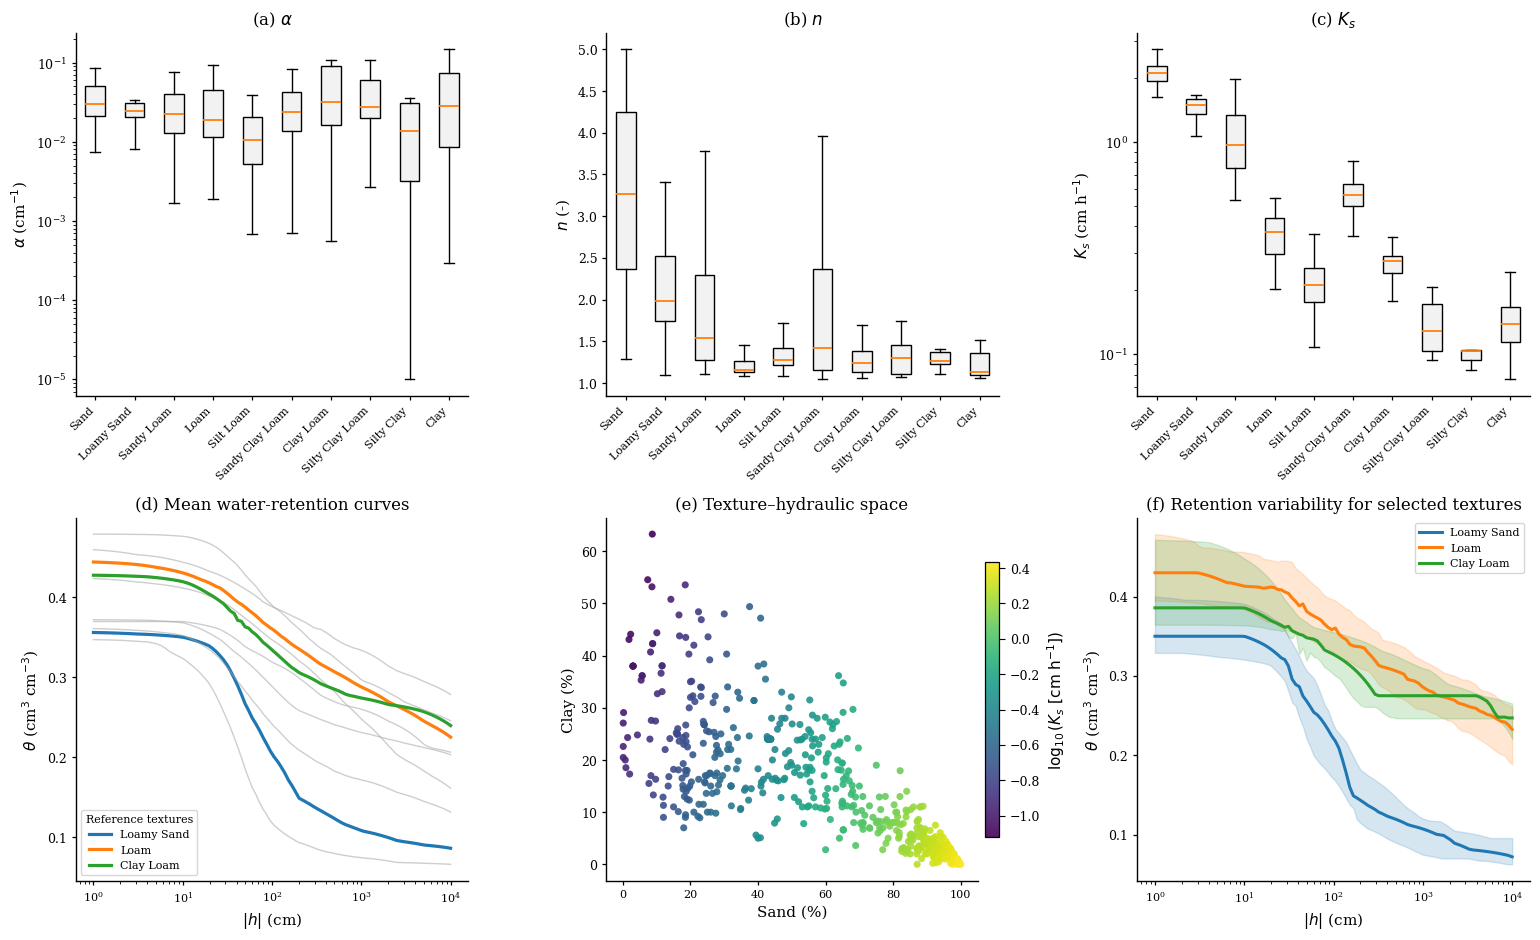


✅ Figure 2 exported: PNG 600 dpi, PDF, and SVG


In [9]:
# ==========================================================
# FIGURE 2 – UNSODA ANALYSIS
# Gregory Guevara
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# Preferred archive filename; legacy filename is accepted for backward compatibility.
UNSODA_CSV = "van_genuchten_with_texture.csv"
if not os.path.isfile(UNSODA_CSV) and os.path.isfile("unsoda.csv"):
    UNSODA_CSV = "unsoda.csv"

if not os.path.isfile(UNSODA_CSV):
    raise FileNotFoundError(
        "UNSODA input file not found. Expected 'van_genuchten_with_texture.csv' "
        "or the legacy filename 'unsoda.csv'."
    )

df = pd.read_csv(UNSODA_CSV)
df.columns = df.columns.str.strip()


# ----------------------------------------------------------
# FUNCTIONS
# ----------------------------------------------------------

def van_genuchten(h, theta_r, theta_s, alpha, n):
    m = 1 - 1 / n
    return theta_r + (theta_s - theta_r) / ((1 + (alpha * h) ** n) ** m)

def remove_outliers_iqr(df_in, col):
    q1 = df_in[col].quantile(0.25)
    q3 = df_in[col].quantile(0.75)
    iqr = q3 - q1
    return df_in[
        (df_in[col] >= q1 - 1.5 * iqr) &
        (df_in[col] <= q3 + 1.5 * iqr)
    ]

# ----------------------------------------------------------
# REQUIRED COLUMNS
# ----------------------------------------------------------

cols_required = [
    "code", "theta", "h_abs", "clay", "silt", "sand",
    "texture_class", "theta_r", "theta_s", "alpha", "n", "Ks"
]

# ----------------------------------------------------------
# CLEANING
# ----------------------------------------------------------

df_clean = df.dropna(subset=cols_required).copy()

numeric_cols = [
    "theta", "h_abs", "clay", "silt", "sand",
    "theta_r", "theta_s", "alpha", "n", "Ks"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean["texture_class"] = df_clean["texture_class"].astype(str).str.strip()

df_clean = df_clean[
    (df_clean["theta"] >= 0) &
    (df_clean["theta"] <= 0.65) &
    (df_clean["h_abs"] > 0) &
    (df_clean["theta_s"] > df_clean["theta_r"]) &
    (df_clean["alpha"] > 0) &
    (df_clean["n"] > 1.0) &
    (df_clean["n"] < 5.5) &
    (df_clean["Ks"] > 0) &
    (df_clean["sand"] >= 0) & (df_clean["sand"] <= 100) &
    (df_clean["silt"] >= 0) & (df_clean["silt"] <= 100) &
    (df_clean["clay"] >= 0) & (df_clean["clay"] <= 100)
].copy()

# ----------------------------------------------------------
# PARAMETER-LEVEL DATASET
# One row per soil/sample code to avoid duplicated parameters
# ----------------------------------------------------------

param_df = (
    df_clean
    .sort_values("code")
    .drop_duplicates(subset=["code"])
    .copy()
)



# Keep only records from accepted soil codes
valid_codes = param_df["code"].unique()
df_clean = df_clean[df_clean["code"].isin(valid_codes)].copy()

# ----------------------------------------------------------
# REMOVE TEXTURE CLASSES WITH VERY FEW SOIL CODES
# ----------------------------------------------------------

MIN_CODES_PER_TEXTURE = 5   # Use 1 if you want to keep all texture classes

texture_counts = param_df.groupby("texture_class")["code"].nunique()

valid_textures = texture_counts[
    texture_counts >= MIN_CODES_PER_TEXTURE
].index.tolist()

param_df = param_df[param_df["texture_class"].isin(valid_textures)].copy()
df_clean = df_clean[df_clean["texture_class"].isin(valid_textures)].copy()

print(f"Original records: {len(df)}")
print(f"Clean measurement records: {len(df_clean)}")
print(f"Unique soil codes after cleaning: {param_df['code'].nunique()}")
print("\nTexture counts used in Figure 2:")
print(param_df.groupby("texture_class")["code"].nunique().sort_values(ascending=False))

# ----------------------------------------------------------
# TEXTURE ORDER – USDA-LIKE ORDER
# ----------------------------------------------------------

usda_order = [
    "Sand", "Loamy Sand", "Sandy Loam", "Loam", "Silt Loam", "Silt",
    "Sandy Clay Loam", "Clay Loam", "Silty Clay Loam",
    "Sandy Clay", "Silty Clay", "Clay"
]

order = [t for t in usda_order if t in param_df["texture_class"].unique()]

# ----------------------------------------------------------
# FOCUS TEXTURES USED IN THE NUMERICAL MODEL
# ----------------------------------------------------------

textures_focus = ["Loamy Sand", "Loam", "Clay Loam"]
textures_focus = [t for t in textures_focus if t in order]

focus_colors = {
    "Loamy Sand": "#1f77b4",
    "Loam": "#ff7f0e",
    "Clay Loam": "#2ca02c"
}

# ----------------------------------------------------------
# STYLE
# ----------------------------------------------------------

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "savefig.dpi": 600
})

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.8))
fig.patch.set_facecolor("white")

# ----------------------------------------------------------
# (a) alpha
# ----------------------------------------------------------

ax = axes[0, 0]

data_alpha = [
    param_df[param_df["texture_class"] == t]["alpha"]
    for t in order
]

bp = ax.boxplot(
    data_alpha,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(linewidth=1.3),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0)
)

for box in bp["boxes"]:
    box.set(facecolor="#f2f2f2")

ax.set_yscale("log")
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title(r"(a) $\alpha$")
ax.set_ylabel(r"$\alpha$ (cm$^{-1}$)")

# ----------------------------------------------------------
# (b) n
# ----------------------------------------------------------

ax = axes[0, 1]

data_n = [
    param_df[param_df["texture_class"] == t]["n"]
    for t in order
]

bp = ax.boxplot(
    data_n,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(linewidth=1.3),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0)
)

for box in bp["boxes"]:
    box.set(facecolor="#f2f2f2")

ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title(r"(b) $n$")
ax.set_ylabel(r"$n$ (-)")

# ----------------------------------------------------------
# (c) Ks
# ----------------------------------------------------------

ax = axes[0, 2]

data_Ks = [
    param_df[param_df["texture_class"] == t]["Ks"]
    for t in order
]

bp = ax.boxplot(
    data_Ks,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(linewidth=1.3),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0)
)

for box in bp["boxes"]:
    box.set(facecolor="#f2f2f2")

ax.set_yscale("log")
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title(r"(c) $K_s$")
ax.set_ylabel(r"$K_s$ (cm h$^{-1}$)")

# ----------------------------------------------------------
# (d) Mean water-retention curves
# All textures shown softly; reference textures highlighted
# ----------------------------------------------------------

ax = axes[1, 0]

h_common = np.logspace(0, 4, 100)

for texture in order:
    subset = df_clean[df_clean["texture_class"] == texture]
    curves = []

    for code, group in subset.groupby("code"):
        group = group.sort_values("h_abs")

        if len(group) < 5:
            continue

        try:
            interp_theta = np.interp(
                h_common,
                group["h_abs"],
                group["theta"]
            )
            curves.append(interp_theta)
        except Exception:
            continue

    if len(curves) > 3:
        mean_curve = np.mean(curves, axis=0)

        if texture in textures_focus:
            ax.plot(
                h_common,
                mean_curve,
                linewidth=2.3,
                label=texture,
                color=focus_colors.get(texture, None)
            )
        else:
            ax.plot(
                h_common,
                mean_curve,
                linewidth=1.0,
                color="0.65",
                alpha=0.55
            )

ax.set_xscale("log")
ax.set_title("(d) Mean water-retention curves")
ax.set_xlabel(r"$|h|$ (cm)")
ax.set_ylabel(r"$\theta$ (cm$^3$ cm$^{-3}$)")
ax.legend(
    loc="lower left",
    frameon=True,
    title="Reference textures",
    fontsize=8,
    title_fontsize=8
)

# ----------------------------------------------------------
# (e) Texture–hydraulic space
# Parameter-level data only
# ----------------------------------------------------------

ax = axes[1, 1]

scatter = ax.scatter(
    param_df["sand"],
    param_df["clay"],
    c=np.log10(param_df["Ks"]),
    cmap="viridis",
    s=26,
    alpha=0.9,
    edgecolors="none"
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label(r"$\log_{10}(K_s\ \mathrm{[cm\ h^{-1}]})$")

ax.set_xlabel("Sand (%)")
ax.set_ylabel("Clay (%)")
ax.set_title("(e) Texture–hydraulic space")

# ----------------------------------------------------------
# (f) Retention variability for selected textures
# Shaded bands = interquartile range
# ----------------------------------------------------------

ax = axes[1, 2]

for texture in textures_focus:
    subset = df_clean[df_clean["texture_class"] == texture]
    curves = []

    for code, group in subset.groupby("code"):
        group = group.sort_values("h_abs")

        if len(group) < 5:
            continue

        try:
            interp_theta = np.interp(
                h_common,
                group["h_abs"],
                group["theta"]
            )
            curves.append(interp_theta)
        except Exception:
            continue

    if len(curves) >= 4:
        curves = np.array(curves)

        q25 = np.percentile(curves, 25, axis=0)
        q50 = np.percentile(curves, 50, axis=0)
        q75 = np.percentile(curves, 75, axis=0)

        color = focus_colors.get(texture, None)

        ax.fill_between(
            h_common,
            q25,
            q75,
            alpha=0.18,
            color=color
        )

        ax.plot(
            h_common,
            q50,
            linewidth=2.2,
            label=texture,
            color=color
        )

ax.set_xscale("log")
ax.set_title("(f) Retention variability for selected textures")
ax.set_xlabel(r"$|h|$ (cm)")
ax.set_ylabel(r"$\theta$ (cm$^3$ cm$^{-3}$)")
ax.legend(frameon=True)

# ----------------------------------------------------------
# GENERAL STYLE
# ----------------------------------------------------------

for ax in axes.flat:
    ax.set_facecolor("white")
    ax.grid(False)
    ax.tick_params(direction="out", length=3, width=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ----------------------------------------------------------
# EXPORTS
# ----------------------------------------------------------

plt.savefig(
    os.path.join(FIGDIR, "Figure_2_UNSODA_variability.png"),
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(FIGDIR, "Figure_2_UNSODA_variability.pdf"),
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(FIGDIR, "Figure_2_UNSODA_variability.svg"),
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\n✅ Figure 2 exported: PNG 600 dpi, PDF, and SVG")

# Figure 4
Solver-aware reference-state selection and trade-offs among non-convergence ratio, storage ratio, runtime, and rescued steps.

C:\Users\gguevara\AppData\Local\Temp\ipykernel_45552\3143294872.py:550: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(
C:\Users\gguevara\AppData\Local\Temp\ipykernel_45552\3143294872.py:557: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(
C:\Users\gguevara\AppData\Local\Temp\ipykernel_45552\3143294872.py:563: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.savefig(
C:\Users\gguevara\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


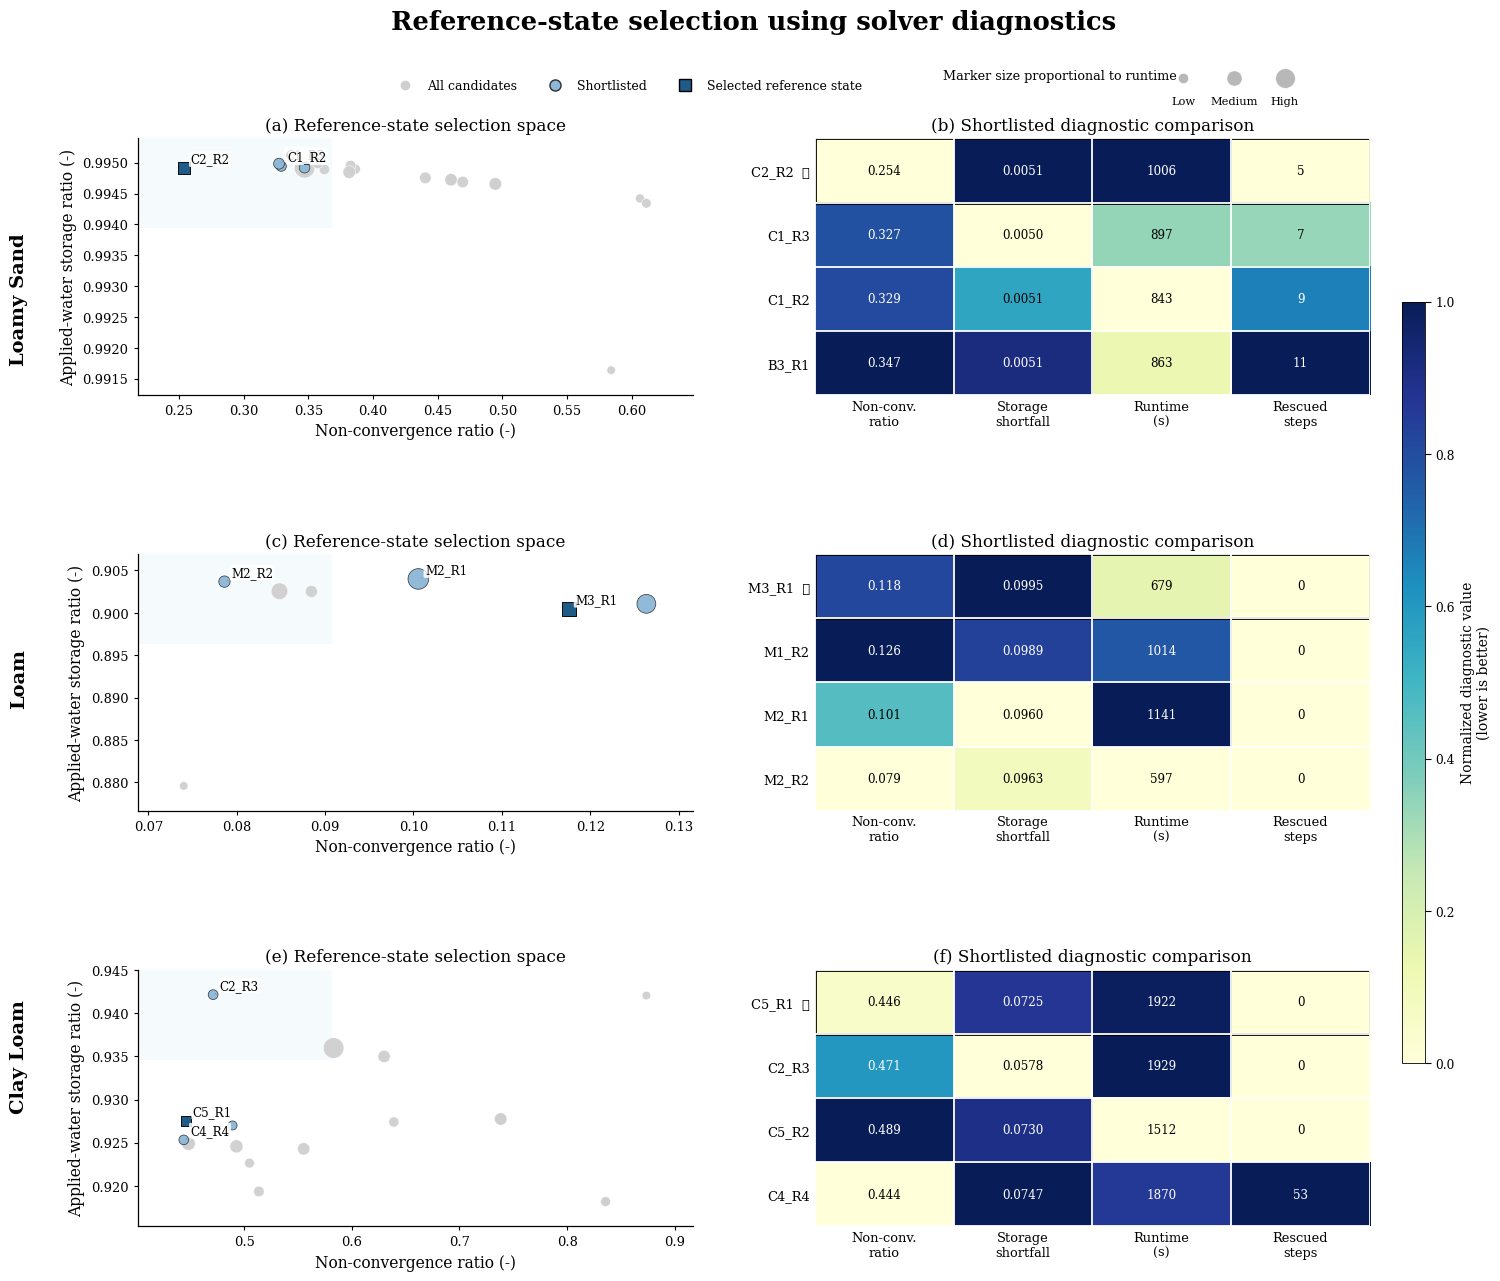

Figure 4 saved in:
- figures\Figure_4_reference_state_selection.png
- figures\Figure_4_reference_state_selection.pdf
- figures\Figure_4_reference_state_selection.svg


In [10]:
# ==========================================================
# FIGURE 4 – REFERENCE-STATE SELECTION
# Gregory Guevara
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FormatStrFormatter

# ==========================================================
# 1. OUTPUT DIRECTORY
# ==========================================================
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# ==========================================================
# 2. STYLE
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10.5,
    "axes.titlesize": 12.2,
    "axes.labelsize": 11.2,
    "xtick.labelsize": 9.4,
    "ytick.labelsize": 9.4,
    "legend.fontsize": 9.0,
    "figure.titlesize": 18.5,
    "axes.linewidth": 0.9
})

# ==========================================================
# 3. COLORS
# ==========================================================

COL_ALL = "#cfcfcf"
COL_SHORTLIST = "#8fb8d8"
COL_SELECTED = "#1f5b87"
COL_EDGE = "#2f2f2f"
COL_TEXTBOX = "#f7f7f7"

# Low values are better, so low normalized values should look lighter.
HEATMAP_CMAP = plt.cm.YlGnBu

# ==========================================================
# 4. DATA
# ==========================================================
coarse_df = pd.read_csv("coarse_results.csv")
medium_df = pd.read_csv("medium_results.csv")
fine_df   = pd.read_csv("fine_results.csv")

# ==========================================================
# 5. SELECTION DEFINITIONS
# ==========================================================

coarse_selected = "C2_R2"
coarse_shortlist = ["C2_R2", "C1_R3", "C1_R2", "B3_R1"]
coarse_annotate = ["C2_R2", "C1_R3", "C1_R2"]

medium_selected = "M3_R1"
medium_shortlist = ["M3_R1", "M1_R2", "M2_R1", "M2_R2"]
medium_annotate = ["M3_R1", "M2_R2", "M2_R1"]

fine_selected = "C5_R1"
fine_shortlist = ["C5_R1", "C2_R3", "C5_R2", "C4_R4"]
fine_annotate = ["C5_R1", "C2_R3", "C4_R4"]

# ==========================================================
# 6. HELPER FUNCTIONS
# ==========================================================

def prepare_df(df, texture_name):
    out = df.copy()
    out["texture_name"] = texture_name
    out["storage_shortfall"] = 1.0 - out["storage_ratio"]
    return out


def marker_sizes(values, smin=38, smax=220):
    values = np.asarray(values, dtype=float)
    vmin, vmax = np.min(values), np.max(values)

    if vmax == vmin:
        return np.full(values.shape, (smin + smax) / 2.0, dtype=float)

    return smin + (values - vmin) * (smax - smin) / (vmax - vmin)


def padded_limits(series, pad_frac=0.08):
    values = np.asarray(series, dtype=float)
    vmin, vmax = np.min(values), np.max(values)
    span = vmax - vmin

    if span == 0:
        span = abs(vmin) * 0.05 if vmin != 0 else 1.0

    return vmin - pad_frac * span, vmax + pad_frac * span


def normalize_columns(df, cols):
    """
    Normalizes each metric column independently.
    Lower values are better for all metrics.
    If all values are equal, the normalized value is set to 0.0
    so that identical zero-risk columns appear as favorable.
    """
    normed = pd.DataFrame(index=df.index)

    for col in cols:
        vals = df[col].astype(float).values
        vmin, vmax = np.min(vals), np.max(vals)

        if vmax == vmin:
            normed[col] = 0.0
        else:
            normed[col] = (vals - vmin) / (vmax - vmin)

    return normed


def style_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.tick_params(direction="out", length=3, width=0.8)


# ==========================================================
# 7. PREPARE GROUP DATA
# ==========================================================

coarse_df = prepare_df(coarse_df, "Loamy Sand")
medium_df = prepare_df(medium_df, "Loam")
fine_df = prepare_df(fine_df, "Clay Loam")

# ==========================================================
# 8. SELECTION SPACE PANELS
# ==========================================================

def plot_selection_space(ax, df, shortlist_ids, selected_id, annotate_ids, panel_title):
    df = df.copy()

    df["is_shortlisted"] = df["ID"].isin(shortlist_ids)
    df["is_selected"] = df["ID"].eq(selected_id)

    sizes = marker_sizes(df["runtime_s"].values)

    xmin, xmax = padded_limits(df["nonconv_ratio"], pad_frac=0.10)
    ymin, ymax = padded_limits(df["storage_ratio"], pad_frac=0.12)

    # Preferred diagnostic region: low non-convergence and high storage ratio.
    ax.add_patch(Rectangle(
        (xmin, ymax - 0.35 * (ymax - ymin)),
        0.35 * (xmax - xmin),
        0.35 * (ymax - ymin),
        facecolor="#eef6fb",
        edgecolor="none",
        alpha=0.55,
        zorder=0
    ))

    mask_all = (~df["is_shortlisted"] & ~df["is_selected"]).to_numpy()
    mask_short = (df["is_shortlisted"] & ~df["is_selected"]).to_numpy()
    mask_sel = df["is_selected"].to_numpy()

    ax.scatter(
        df.loc[mask_all, "nonconv_ratio"],
        df.loc[mask_all, "storage_ratio"],
        s=sizes[mask_all],
        c=COL_ALL,
        edgecolor="white",
        linewidth=0.4,
        alpha=0.95,
        zorder=1
    )

    ax.scatter(
        df.loc[mask_short, "nonconv_ratio"],
        df.loc[mask_short, "storage_ratio"],
        s=sizes[mask_short],
        c=COL_SHORTLIST,
        edgecolor=COL_EDGE,
        linewidth=0.5,
        alpha=0.98,
        zorder=2
    )

    ax.scatter(
        df.loc[mask_sel, "nonconv_ratio"],
        df.loc[mask_sel, "storage_ratio"],
        s=sizes[mask_sel] * 1.12,
        c=COL_SELECTED,
        edgecolor="black",
        linewidth=0.65,
        marker="s",
        alpha=1.0,
        zorder=3
    )

    for rid in annotate_ids:
        row = df[df["ID"] == rid].iloc[0]

        dx = 0.012 * (xmax - xmin)
        dy = 0.010 * (ymax - ymin)

        ax.annotate(
            rid,
            xy=(row["nonconv_ratio"], row["storage_ratio"]),
            xytext=(row["nonconv_ratio"] + dx, row["storage_ratio"] + dy),
            fontsize=8.6,
            ha="left",
            va="bottom",
            arrowprops=dict(
                arrowstyle="-",
                color="0.35",
                lw=0.55,
                shrinkA=2,
                shrinkB=2
            ),
            bbox=dict(
                boxstyle="round,pad=0.12",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            ),
            zorder=4
        )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(panel_title, pad=6)
    ax.set_xlabel("Non-convergence ratio (-)")
    ax.set_ylabel("Applied-water storage ratio (-)")

    style_axis(ax)


# ==========================================================
# 9. SHORTLIST HEATMAP PANELS
# ==========================================================

def plot_shortlist_heatmap(ax, df, shortlist_ids, selected_id, panel_title):
    shortlist = df[df["ID"].isin(shortlist_ids)].copy()

    order_map = {sid: i for i, sid in enumerate(shortlist_ids)}
    shortlist["order"] = shortlist["ID"].map(order_map)
    shortlist = shortlist.sort_values("order").reset_index(drop=True)

    metric_cols = [
        "nonconv_ratio",
        "storage_shortfall",
        "runtime_s",
        "rescued_steps"
    ]

    metric_labels = [
        "Non-conv.\nratio",
        "Storage\nshortfall",
        "Runtime\n(s)",
        "Rescued\nsteps"
    ]

    normed = normalize_columns(shortlist, metric_cols)
    heat = normed[metric_cols].values

    ax.imshow(
        heat,
        cmap=HEATMAP_CMAP,
        aspect="auto",
        vmin=0,
        vmax=1
    )

    ylabels = shortlist["ID"].tolist()
    ylabels = [f"{label}  ★" if label == selected_id else label for label in ylabels]

    ax.set_yticks(np.arange(len(ylabels)))
    ax.set_yticklabels(ylabels)

    ax.set_xticks(np.arange(len(metric_labels)))
    ax.set_xticklabels(metric_labels)

    ax.set_title(panel_title, pad=6)

    ax.set_xticks(np.arange(-0.5, heat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, heat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Actual values inside heatmap cells.
    for i in range(shortlist.shape[0]):
        for j, col in enumerate(metric_cols):
            value = shortlist.loc[i, col]

            if col == "nonconv_ratio":
                text_value = f"{value:.3f}"
            elif col == "storage_shortfall":
                text_value = f"{value:.4f}"
            elif col == "runtime_s":
                text_value = f"{value:.0f}"
            elif col == "rescued_steps":
                text_value = f"{int(value)}"
            else:
                text_value = str(value)

            text_color = "black" if heat[i, j] < 0.60 else "white"

            ax.text(
                j,
                i,
                text_value,
                ha="center",
                va="center",
                fontsize=8.6,
                color=text_color
            )

    # Highlight selected row.
    selected_row = shortlist.index[shortlist["ID"] == selected_id][0]

    ax.add_patch(Rectangle(
        (-0.5, selected_row - 0.5),
        width=len(metric_cols),
        height=1,
        fill=False,
        edgecolor="black",
        linewidth=2.0
    ))

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)


# ==========================================================
# 10. FIGURE LAYOUT
# ==========================================================

fig, axs = plt.subplots(3, 2, figsize=(15.8, 13.6))

fig.patch.set_facecolor("white")

fig.subplots_adjust(
    left=0.11,
    right=0.89,
    bottom=0.08,
    top=0.88,
    wspace=0.22,
    hspace=0.62
)

# Row 1 – Loamy Sand
plot_selection_space(
    axs[0, 0],
    coarse_df,
    shortlist_ids=coarse_shortlist,
    selected_id=coarse_selected,
    annotate_ids=coarse_annotate,
    panel_title="(a) Reference-state selection space"
)

plot_shortlist_heatmap(
    axs[0, 1],
    coarse_df,
    shortlist_ids=coarse_shortlist,
    selected_id=coarse_selected,
    panel_title="(b) Shortlisted diagnostic comparison"
)

# Row 2 – Loam
plot_selection_space(
    axs[1, 0],
    medium_df,
    shortlist_ids=medium_shortlist,
    selected_id=medium_selected,
    annotate_ids=medium_annotate,
    panel_title="(c) Reference-state selection space"
)

plot_shortlist_heatmap(
    axs[1, 1],
    medium_df,
    shortlist_ids=medium_shortlist,
    selected_id=medium_selected,
    panel_title="(d) Shortlisted diagnostic comparison"
)

# Row 3 – Clay Loam
plot_selection_space(
    axs[2, 0],
    fine_df,
    shortlist_ids=fine_shortlist,
    selected_id=fine_selected,
    annotate_ids=fine_annotate,
    panel_title="(e) Reference-state selection space"
)

plot_shortlist_heatmap(
    axs[2, 1],
    fine_df,
    shortlist_ids=fine_shortlist,
    selected_id=fine_selected,
    panel_title="(f) Shortlisted diagnostic comparison"
)

# ==========================================================
# 11. ROW LABELS
# ==========================================================

fig.text(0.035, 0.762, "Loamy Sand", fontsize=14.0, fontweight="semibold",
         ha="center", va="center", rotation=90)

fig.text(0.035, 0.483, "Loam", fontsize=14.0, fontweight="semibold",
         ha="center", va="center", rotation=90)

fig.text(0.035, 0.205, "Clay Loam", fontsize=14.0, fontweight="semibold",
         ha="center", va="center", rotation=90)

# ==========================================================
# 12. LEGENDS
# ==========================================================

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="All candidates",
        markerfacecolor=COL_ALL,
        markeredgecolor="white",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Shortlisted",
        markerfacecolor=COL_SHORTLIST,
        markeredgecolor=COL_EDGE,
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="Selected reference state",
        markerfacecolor=COL_SELECTED,
        markeredgecolor="black",
        markersize=8
    )
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.42, 0.932),
    ncol=3,
    frameon=False
)

# Marker-size legend
size_ax = fig.add_axes([0.62, 0.902, 0.23, 0.045])
size_ax.axis("off")

size_ax.text(
    0.00,
    0.53,
    "Marker size proportional to runtime",
    ha="left",
    va="center",
    fontsize=9.2
)

for x, size, label in zip([0.66, 0.80, 0.94], [55, 120, 200], ["Low", "Medium", "High"]):
    size_ax.scatter(
        x,
        0.50,
        s=size,
        color="#b8b8b8",
        edgecolor="white",
        linewidth=0.4
    )

    size_ax.text(
        x,
        0.03,
        label,
        ha="center",
        va="bottom",
        fontsize=8.2
    )

size_ax.set_xlim(0, 1)
size_ax.set_ylim(0, 1)

# ==========================================================
# 13. HEATMAP COLORBAR
# ==========================================================

cax = fig.add_axes([0.91, 0.20, 0.015, 0.56])

sm = ScalarMappable(
    norm=Normalize(vmin=0, vmax=1),
    cmap=HEATMAP_CMAP
)

sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)

cbar.set_label(
    "Normalized diagnostic value\n(lower is better)",
    fontsize=10.0
)

cbar.ax.tick_params(labelsize=8.8)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
cbar.outline.set_linewidth(0.6)

# ==========================================================
# 14. TITLE
# ==========================================================

fig.suptitle(
    "Reference-state selection using solver diagnostics",
    fontweight="bold",
    y=0.975
)

# ==========================================================
# 15. SAVE
# ==========================================================

png_path = os.path.join(FIGDIR, "Figure_4_reference_state_selection.png")
pdf_path = os.path.join(FIGDIR, "Figure_4_reference_state_selection.pdf")
svg_path = os.path.join(FIGDIR, "Figure_4_reference_state_selection.svg")

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure 4 saved in:\n- {png_path}\n- {pdf_path}\n- {svg_path}")

# Figure 5
Representative wetting-bulb geometries and selected hydraulic responses across soil textures under selected reference states.

Domain: R=50.0 cm, Z=50.0 cm
Grid: nr=50, nz=50, N=2500
Reference-state consistency check:
OK: Loamy Sand: Figure 5 = C2_R2 | Figure 4 expected = C2_R2
OK: Loam: Figure 5 = M3_R1 | Figure 4 expected = M3_R1
OK: Clay Loam: Figure 5 = C5_R1 | Figure 4 expected = C5_R1


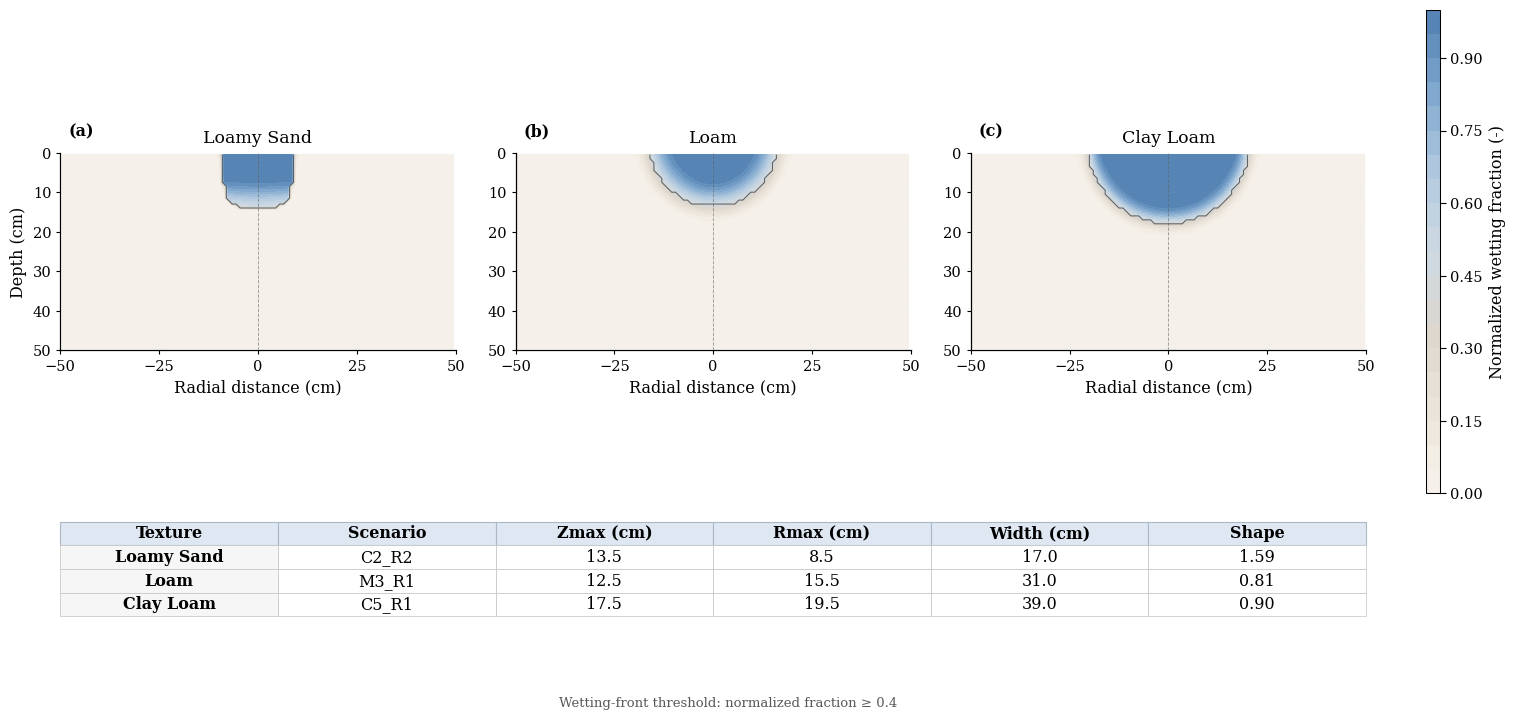

Figure 5 exported:
- figures\Figure_5_selected_wetting_bulbs.png
- figures\Figure_5_selected_wetting_bulbs.pdf
- figures\Figure_5_selected_wetting_bulbs.svg

Integrated geometry table:
      Texture Scenario Zmax (cm) Rmax (cm) Width (cm) Shape
0  Loamy Sand    C2_R2      13.5       8.5       17.0  1.59
1        Loam    M3_R1      12.5      15.5       31.0  0.81
2   Clay Loam    C5_R1      17.5      19.5       39.0  0.90


In [11]:
# ==========================================================
# FIGURE 5 – REPRESENTATIVE WETTING-BULB GEOMETRIES
# REPRODUCIBILITY RELEASE
# 1x3 panels + integrated geometry table
# Gregory Guevara
# ==========================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec


# ----------------------------------------------------------
# AXISYMMETRIC DOMAIN
# ----------------------------------------------------------
Rmax = 50.0   # cm
Zmax = 50.0   # cm
dr = 1.0      # cm
dz = 1.0      # cm

nr = int(Rmax / dr)
nz = int(Zmax / dz)
N = nr * nz

r = (np.arange(nr) + 0.5) * dr
z = (np.arange(nz) + 0.5) * dz

print(f"Domain: R={Rmax} cm, Z={Zmax} cm")
print(f"Grid: nr={nr}, nz={nz}, N={N}")

# ==========================================================
# 1. INPUT FILES
# ==========================================================

master_results_pkl = os.path.join("master_results_eqtime_1p8h.pkl")

if not os.path.exists(master_results_pkl):
    raise FileNotFoundError(f"File not found: {master_results_pkl}")

with open(master_results_pkl, "rb") as f:
    master_results = pickle.load(f)

# ==========================================================
# 2. OUTPUT DIRECTORY
# ==========================================================

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# ==========================================================
# 3. THRESHOLD SETTINGS
# ==========================================================
# Keep this threshold definition consistent with Methods, Results,
# captions, and Supplementary Material.

THRESHOLD_MODE = "normalized_fraction"
FW_THRESHOLD = 0.40


# Alternative, only if your manuscript defines fw as absolute delta theta:
# THRESHOLD_MODE = "delta_theta"
# FW_THRESHOLD = 0.04

# ==========================================================
# 4. STYLE
# ==========================================================

BASE_FS = 11.5

plt.rcParams.update({
    "font.family": "serif",
    "font.size": BASE_FS,
    "axes.titlesize": BASE_FS + 1.0,
    "axes.labelsize": BASE_FS,
    "xtick.labelsize": BASE_FS - 1.0,
    "ytick.labelsize": BASE_FS - 1.0,
    "legend.fontsize": BASE_FS - 1.5,
    "axes.linewidth": 0.9,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

# ==========================================================
# 5. COLOR PALETTE
# ==========================================================

soil_water_cmap = LinearSegmentedColormap.from_list(
    "soil_water_cmap_master",
    [
        (247/255, 243/255, 237/255),
        (236/255, 229/255, 218/255),
        (220/255, 214/255, 205/255),
        (206/255, 217/255, 227/255),
        (177/255, 201/255, 223/255),
        (127/255, 167/255, 206/255),
        (79/255, 126/255, 177/255),
    ]
)

# ==========================================================
# 6. AUXILIARY FUNCTIONS
# ==========================================================

def mirror_field(rvals, field2d):
    """
    Mirrors an axisymmetric field around r = 0 for visualization.
    """
    r_plot = np.concatenate((-rvals[::-1], rvals))
    field_plot = np.hstack((field2d[:, ::-1], field2d))
    return r_plot, field_plot


def compute_wetting_metrics(
    theta2d,
    theta_init,
    soil,
    fw_threshold=0.40,
    threshold_mode="normalized_fraction"
):
    """
    Computes wetting fraction, wetting-front mask, and geometric metrics.

    threshold_mode:
    - "normalized_fraction": threshold is applied to normalized wetting fraction:
      (theta - theta_init) / (theta_s - theta_init)

    - "delta_theta": threshold is applied directly to:
      theta - theta_init
    """

    theta_s = soil["theta_s"]
    delta_theta = theta2d - theta_init

    wet_frac = delta_theta / (theta_s - theta_init + 1e-12)
    wet_frac = np.clip(wet_frac, 0.0, 1.0)

    if threshold_mode == "normalized_fraction":
        wet_mask = wet_frac >= fw_threshold

    elif threshold_mode == "delta_theta":
        wet_mask = delta_theta >= fw_threshold

    else:
        raise ValueError(
            "threshold_mode must be either 'normalized_fraction' or 'delta_theta'"
        )

    z_idx = np.where(np.any(wet_mask, axis=1))[0]
    r_idx = np.where(np.any(wet_mask, axis=0))[0]

    depth = z[z_idx.max()] if len(z_idx) > 0 else np.nan
    radial_extent = r[r_idx.max()] if len(r_idx) > 0 else np.nan
    width = 2.0 * radial_extent if np.isfinite(radial_extent) else np.nan

    if np.isfinite(depth) and np.isfinite(radial_extent) and radial_extent > 0:
        shape = depth / radial_extent
    else:
        shape = np.nan

    return {
        "wet_frac": wet_frac,
        "wet_mask": wet_mask,
        "depth": depth,
        "radial_extent": radial_extent,
        "width": width,
        "shape": shape
    }


def style_bulb_axis(ax, show_ylabel=False):
    """
    Applies common formatting to wetting-bulb panels.
    """
    ax.set_xlim(-50, 50)
    ax.set_ylim(50, 0)

    ax.set_xticks([-50, -25, 0, 25, 50])
    ax.set_yticks([0, 10, 20, 30, 40, 50])

    ax.set_aspect("equal")

    ax.grid(
        True,
        which="major",
        color="#d0d0d0",
        linewidth=0.25,
        alpha=0.15
    )

    # Emitter axis, represented only as a subtle dashed line.
    ax.axvline(
        0,
        color="0.35",
        linewidth=0.65,
        linestyle="--",
        alpha=0.55,
        zorder=5
    )

    if show_ylabel:
        ax.set_ylabel("Depth (cm)", fontsize=BASE_FS)

    ax.set_xlabel("Radial distance (cm)", fontsize=BASE_FS)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    ax.tick_params(
        axis="both",
        direction="out",
        length=3.0,
        width=0.8
    )


def build_geometry_table_df(master_results):
    """
    Builds table with geometry metrics only.
    Non-convergence and storage metrics are intentionally excluded because
    they are reported in Figure 4 and Supplementary Tables.
    """

    rows = []

    for tex in ["Loamy Sand", "Loam", "Clay Loam"]:

        soil = master_results[tex]["soil"]
        cfg = master_results[tex]["cfg"]
        sim = master_results[tex]["sim"]

        theta2d = sim["theta2d"]
        theta_init = sim["theta_init"]

        met = compute_wetting_metrics(
            theta2d=theta2d,
            theta_init=theta_init,
            soil=soil,
            fw_threshold=FW_THRESHOLD,
            threshold_mode=THRESHOLD_MODE
        )

        rows.append({
            "Texture": tex,
            "Scenario": cfg["phase_run_id"],
            "Zmax (cm)": f"{met['depth']:.1f}",
            "Rmax (cm)": f"{met['radial_extent']:.1f}",
            "Width (cm)": f"{met['width']:.1f}",
            "Shape": f"{met['shape']:.2f}",
        })

    return pd.DataFrame(rows)

# ==========================================================
# 7. CHECK SCENARIO CONSISTENCY WITH FIGURE 4
# ==========================================================

expected_selected = {
    "Loamy Sand": "C2_R2",
    "Loam": "M3_R1",
    "Clay Loam": "C5_R1"
}

print("Reference-state consistency check:")

for tex, expected_id in expected_selected.items():
    current_id = master_results[tex]["cfg"]["phase_run_id"]
    status = "OK" if current_id == expected_id else "CHECK"
    print(f"{status}: {tex}: Figure 5 = {current_id} | Figure 4 expected = {expected_id}")

# ==========================================================
# 8. FIGURE LAYOUT
# ==========================================================

textures_plot = ["Loamy Sand", "Loam", "Clay Loam"]

fig = plt.figure(figsize=(17.8, 8.05))
fig.patch.set_facecolor("white")

gs = GridSpec(
    2,
    4,
    figure=fig,
    width_ratios=[1, 1, 1, 0.035],
    height_ratios=[4.8, 1.20],
    wspace=0.20,
    hspace=0.05
)

axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_table = fig.add_subplot(gs[1, 0:3])

# Colorbar aligned only with upper panels.
cax = fig.add_subplot(gs[0, 3])

cf_last = None

# ==========================================================
# 9. PLOT BULBS
# ==========================================================

for i, tex in enumerate(textures_plot):

    ax = axes_top[i]

    soil = master_results[tex]["soil"]
    cfg = master_results[tex]["cfg"]
    sim = master_results[tex]["sim"]

    theta2d = sim["theta2d"]
    theta_init = sim["theta_init"]


    met = compute_wetting_metrics(
        theta2d=theta2d,
        theta_init=theta_init,
        soil=soil,
        fw_threshold=FW_THRESHOLD,
        threshold_mode=THRESHOLD_MODE
    )

    wet_frac = met["wet_frac"]
    wet_mask = met["wet_mask"]

    r_plot, frac_plot = mirror_field(r, wet_frac)
    _, mask_plot = mirror_field(r, wet_mask.astype(float))

    RR, ZZ = np.meshgrid(r_plot, z)

    cf = ax.contourf(
        RR,
        ZZ,
        frac_plot,
        levels=np.linspace(0, 1, 21),
        cmap=soil_water_cmap,
        extend="neither"
    )

    # Wetting-front contour.
    ax.contour(
        RR,
        ZZ,
        mask_plot,
        levels=[0.5],
        colors="#525252",
        linewidths=0.75,
        alpha=0.90
    )

    style_bulb_axis(ax, show_ylabel=(i == 0))

    # Texture title.
    ax.set_title(
        tex,
        fontsize=BASE_FS + 1.0,
        pad=7
    )

    # Panel label, slightly higher to avoid collision with panel title.
    ax.text(
        0.02,
        1.065,
        f"({chr(97 + i)})",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=BASE_FS,
        fontweight="bold"
    )

    cf_last = cf

# ==========================================================
# 10. INTEGRATED GEOMETRY TABLE
# ==========================================================

ax_table.axis("off")

summary_table_df = build_geometry_table_df(master_results)

table = ax_table.table(
    cellText=summary_table_df.values,
    colLabels=summary_table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(BASE_FS)
table.scale(1.0, 1.42)

for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight="bold", color="black")
        cell.set_facecolor("#dfe8f2")
        cell.set_edgecolor("#aab8c6")
        cell.set_linewidth(0.8)

    else:
        cell.set_facecolor("white")
        cell.set_edgecolor("#c7c7c7")
        cell.set_linewidth(0.55)

# Texture column emphasized.
for row in range(1, len(summary_table_df) + 1):
    table[(row, 0)].set_text_props(weight="bold")
    table[(row, 0)].set_facecolor("#f6f6f6")

# ==========================================================
# 11. COLORBAR
# ==========================================================

cbar = fig.colorbar(cf_last, cax=cax)

cbar.set_label(
    "Normalized wetting fraction (-)",
    fontsize=BASE_FS
)

cbar.ax.tick_params(labelsize=BASE_FS - 1)
cbar.outline.set_linewidth(0.75)

# ==========================================================
# 12. SMALL NOTE
# ==========================================================

threshold_label = (
    f"Wetting-front threshold: {THRESHOLD_MODE.replace('_', ' ')} ≥ {FW_THRESHOLD}"
)

fig.text(
    0.50,
    0.018,
    threshold_label,
    ha="center",
    va="center",
    fontsize=BASE_FS - 2.0,
    color="0.35"
)

# ==========================================================
# 13. EXPORTS
# ==========================================================

png_path = os.path.join(
    FIGDIR,
    "Figure_5_selected_wetting_bulbs.png"
)

pdf_path = png_path.replace(".png", ".pdf")
svg_path = png_path.replace(".png", ".svg")

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    svg_path,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Figure 5 exported:")
print(f"- {png_path}")
print(f"- {pdf_path}")
print(f"- {svg_path}")

print("\nIntegrated geometry table:")
print(summary_table_df)

# Figure 6
Temporal evolution of wetting-bulb geometry under varying emitter discharge rates.

CSV cargado correctamente
File: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\table_A3_qt_response_loam_v3.csv
Selected texture: Loam
Detected discharge levels: [0.5, 1.0, 2.0, 4.0]


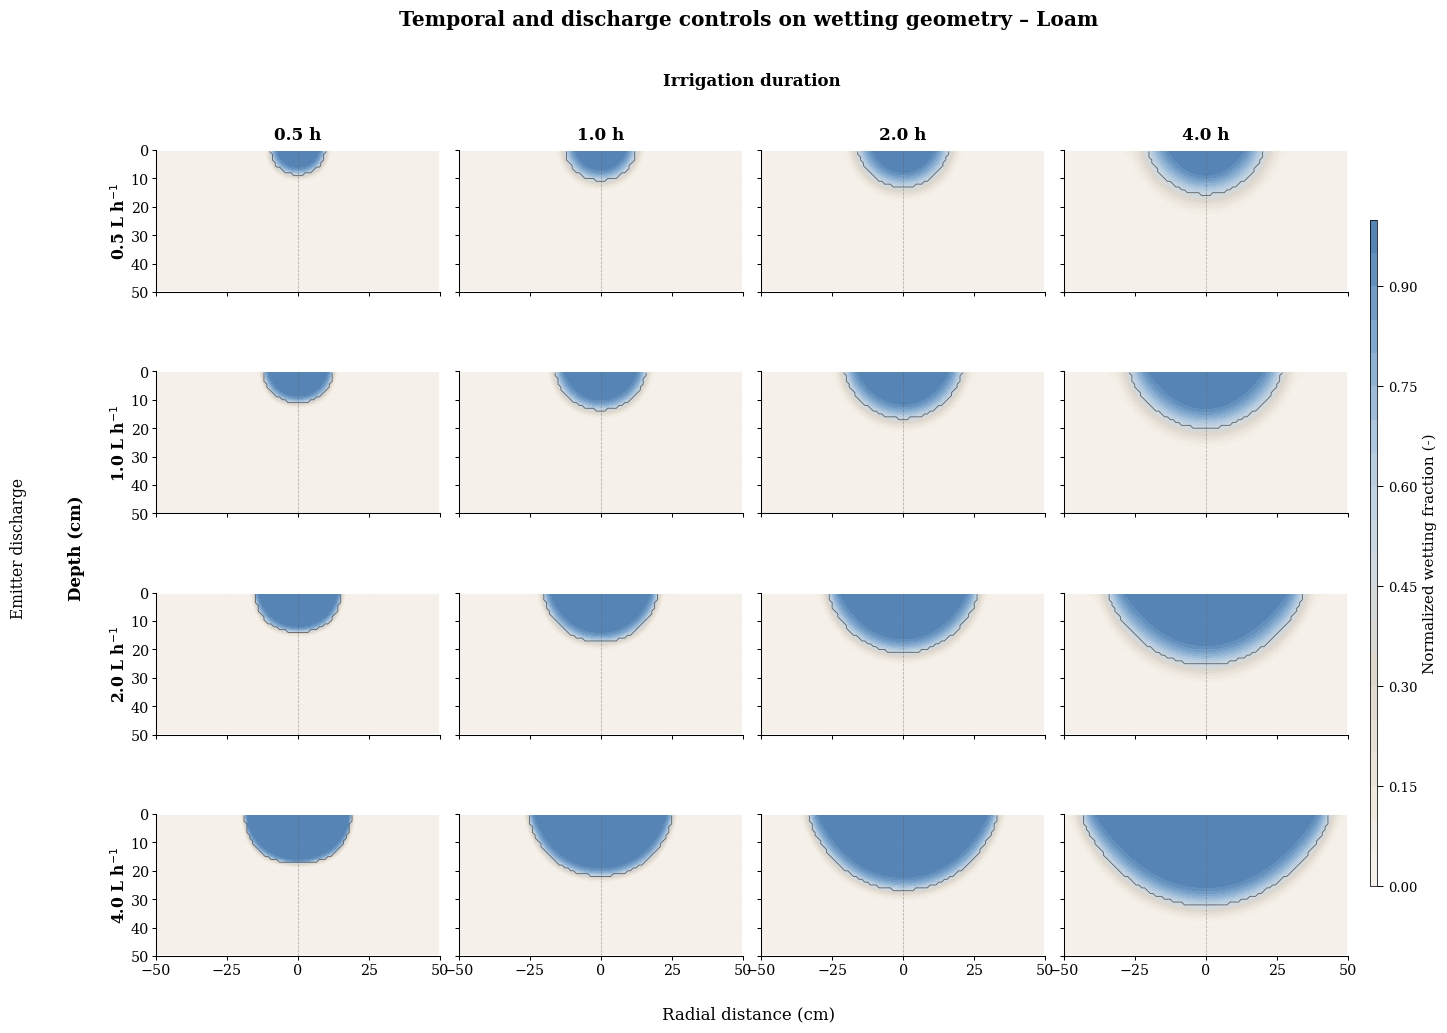


FIGURE 6 GENERATED SUCCESSFULLY
PNG: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_6_discharge_time_Loam.png
PDF: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_6_discharge_time_Loam.pdf
SVG: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_6_discharge_time_Loam.svg
Metrics CSV: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_6_discharge_time_Loam_metrics.csv


In [12]:
# ==========================================================
# FIGURE 6 – DISCHARGE × TIME MATRIX FOR SELECTED SOIL TEXTURE
# STANDALONE VERSION: READS CSV + NPZ DIRECTLY
# DOES NOT REQUIRE EXECUTION OF AN EARLIER BLOCK
# ==========================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec


# ==========================================================
# 1. USER CONFIGURATION
# ==========================================================

# Archive root directory. Run the notebook from the extracted repository root.
PROJECT_DIR = Path.cwd()

NPZ_DIR = PROJECT_DIR / "npz_runs"

FIG6_CSV = PROJECT_DIR / "table_A3_qt_response_loam_v3.csv"

# Directory used for figure exports
FIGDIR = PROJECT_DIR / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)


# ==========================================================
# 2. FIGURE SELECTION
# ==========================================================

# Texture displayed
QT_TEXTURE = "Loam"

# Times displayed in columns
QT_SNAPSHOT_TIMES_H = [0.5, 1.0, 2.0, 4.0]

# Time associated with the final theta2d and theta_init arrays
FINAL_TIME_H = 4.0

# Plot limits
PLOT_RMAX = 50.0
PLOT_ZMAX = 50.0

# Show metrics in each panel
SHOW_PANEL_METRICS = False

# Show Zmax and Rmax only at later times
SHOW_LATE_TIME_GEOMETRY = False


# ==========================================================
# 3. OPTIONAL CSV FILTERS
# ==========================================================

# Use this option only if the CSV contains more than one
# row for the same texture × discharge combination.
#
# Examples:
#
# CSV_FILTERS = {
#     "scenario": "H1_ref_4h_fw50"
# }
#
# CSV_FILTERS = {
#     "state": "selected"
# }
#
# Leave empty when there is only one row per discharge.

CSV_FILTERS = {}


# ==========================================================
# 4. GRID CONFIGURATION
# ==========================================================

# These values are used only if the NPZ files do not contain
# coordinate vectors named "r" and "z".

DEFAULT_DR_CM = 1.0
DEFAULT_DZ_CM = 1.0


# ==========================================================
# 5. EXPORT CONFIGURATION
# ==========================================================

EXPORT_PNG = True
EXPORT_PDF = True
EXPORT_SVG = True
EXPORT_METRICS_CSV = True


# ==========================================================
# 6. COLOR PALETTE
# ==========================================================

soil_water_cmap = LinearSegmentedColormap.from_list(
    "soil_water_cmap",
    [
        (247 / 255, 243 / 255, 237 / 255),
        (236 / 255, 229 / 255, 218 / 255),
        (220 / 255, 214 / 255, 205 / 255),
        (206 / 255, 217 / 255, 227 / 255),
        (177 / 255, 201 / 255, 223 / 255),
        (127 / 255, 167 / 255, 206 / 255),
        (79 / 255, 126 / 255, 177 / 255),
    ]
)


# ==========================================================
# 7. HELPER FUNCTIONS
# ==========================================================

def require_file(path, description):
    """
    Checks that a required file exists.
    """
    path = Path(path)

    if not path.is_file():
        raise FileNotFoundError(
            f"\nCould not find {description}:\n"
            f"{path}\n\n"
            "Check PROJECT_DIR, the filename, and the directory structure "
            "of the archive."
        )


def load_npz_raw(npz_path):
    """
    Opens an NPZ file and loads all arrays into memory.
    """
    npz_path = Path(npz_path)

    require_file(npz_path, "the NPZ file")

    with np.load(npz_path, allow_pickle=True) as npz_file:
        return {
            key: npz_file[key]
            for key in npz_file.files
        }


def prepare_theta_init(theta2d, theta_init):
    """
    Converts theta_init to an array compatible with theta2d.

    theta_init may be:
    - a 2D array;
    - a scalar;
    - an array that can be expanded by broadcasting.
    """
    theta2d = np.asarray(theta2d, dtype=float)
    theta_init = np.asarray(theta_init, dtype=float)

    if theta_init.ndim == 0:
        return np.full_like(
            theta2d,
            float(theta_init),
            dtype=float
        )

    try:
        theta_init = np.broadcast_to(
            theta_init,
            theta2d.shape
        ).astype(float)

    except ValueError as error:
        raise ValueError(
            "theta_init cannot be broadcast to the dimensions of theta2d.\n"
            f"theta2d: {theta2d.shape}\n"
            f"theta_init: {theta_init.shape}"
        ) from error

    return theta_init


def possible_snapshot_tags(time_h):
    """
    Generates candidate tags for locating snapshots in the NPZ file.

    For example:
        0.5 -> 0_5
        1.0 -> 1_0 y 1
        2.0 -> 2_0 y 2
    """
    time_h = float(time_h)

    tags = [
        str(time_h).replace(".", "_"),
        f"{time_h:g}".replace(".", "_"),
    ]

    # Remove duplicate tags while preserving order
    return list(dict.fromkeys(tags))


def find_snapshot_key(npz_data, prefix, time_h):
    """
    Searches for a snapshot array using supported naming formats.
    """
    for tag in possible_snapshot_tags(time_h):

        key = f"{prefix}_{tag}"

        if key in npz_data:
            return key

    return None


def choose_snapshot(
    npz_data,
    target_time_h,
    final_time_h=4.0
):
    """
    Selects the snapshot corresponding to the requested time.

    A missing intermediate time is not silently replaced with the final
    state. If a requested snapshot is missing, a clear error is raised.
    """

    target_time_h = float(target_time_h)

    theta_key = find_snapshot_key(
        npz_data,
        "theta2d_t",
        target_time_h
    )

    theta_init_key = find_snapshot_key(
        npz_data,
        "theta_init_t",
        target_time_h
    )

    # Case 1: a specific snapshot exists
    if theta_key is not None:

        theta2d = np.asarray(
            npz_data[theta_key],
            dtype=float
        )

        if theta_init_key is not None:
            theta_init = npz_data[theta_init_key]

        elif "theta_init" in npz_data:
            theta_init = npz_data["theta_init"]

        else:
            raise KeyError(
                f"Found '{theta_key}', but no matching theta_init "
                "was found for that time and no global 'theta_init' "
                "array is available."
            )

        theta_init = prepare_theta_init(
            theta2d,
            theta_init
        )

        return theta2d, theta_init

    # Case 2: use the final arrays for the final time
    if np.isclose(
        target_time_h,
        final_time_h,
        rtol=0.0,
        atol=1e-8
    ):

        if "theta2d" not in npz_data:
            raise KeyError(
                "The NPZ file does not contain the final 'theta2d' array."
            )

        if "theta_init" not in npz_data:
            raise KeyError(
                "The NPZ file does not contain the initial 'theta_init' array."
            )

        theta2d = np.asarray(
            npz_data["theta2d"],
            dtype=float
        )

        theta_init = prepare_theta_init(
            theta2d,
            npz_data["theta_init"]
        )

        return theta2d, theta_init

    # Case 3: requested snapshot is unavailable
    available_keys = sorted(
        key
        for key in npz_data
        if key.startswith("theta2d_t_")
    )

    raise KeyError(
        f"\nSnapshot at {target_time_h:g} h was not found.\n\n"
        f"Available keys:\n{available_keys}\n\n"
        "Check whether the NPZ file contains that time."
    )


def normalize_wetting_fraction(theta2d, theta_init):
    """
    Computes the normalized wetting fraction from the water-content increase.
    """
    theta2d = np.asarray(theta2d, dtype=float)

    theta_init = prepare_theta_init(
        theta2d,
        theta_init
    )

    if theta2d.ndim != 2:
        raise ValueError(
            "theta2d must be a two-dimensional array.\n"
            f"Received shape: {theta2d.shape}"
        )

    dtheta = theta2d - theta_init

    if not np.any(np.isfinite(dtheta)):
        raise ValueError(
            "The difference theta2d - theta_init contains no "
            "finite values."
        )

    dmax = float(np.nanmax(dtheta))

    if not np.isfinite(dmax) or dmax <= 0:
        return np.zeros_like(
            dtheta,
            dtype=float
        )

    wet_frac = dtheta / dmax

    return np.clip(
        wet_frac,
        0.0,
        1.0
    )


def build_wet_mask(wet_frac, fw_threshold):
    """
    Builds the mask corresponding to the wetting front.
    """
    fw_threshold = float(fw_threshold)

    if not 0.0 <= fw_threshold <= 1.0:
        raise ValueError(
            "fw_threshold must be between 0 and 1.\n"
            f"Received value: {fw_threshold}"
        )

    return wet_frac >= fw_threshold


def mirror_field(r_values, field2d):
    """
    Mirrors the radial domain to represent both sides
    of the emitter.
    """
    r_values = np.asarray(
        r_values,
        dtype=float
    )

    field2d = np.asarray(field2d)

    if field2d.ndim != 2:
        raise ValueError(
            f"field2d must be 2D. Received shape: {field2d.shape}"
        )

    if field2d.shape[1] != len(r_values):
        raise ValueError(
            "The length of r does not match the number of "
            "columns of field2d.\n"
            f"len(r): {len(r_values)}\n"
            f"columns: {field2d.shape[1]}"
        )

    r_plot = np.concatenate(
        (
            -r_values[::-1],
            r_values
        )
    )

    field_plot = np.hstack(
        (
            field2d[:, ::-1],
            field2d
        )
    )

    return r_plot, field_plot


def coordinates_from_npz(npz_data, field_shape):
    """
    Obtains r and z coordinates from the NPZ file.

    If the NPZ file does not contain r and z, they are constructed
    using the user-defined default grid spacing.
    """
    nz, nr = field_shape

    # Radial coordinate
    if "r" in npz_data:

        r_values = np.asarray(
            npz_data["r"],
            dtype=float
        ).ravel()

        if len(r_values) != nr:
            raise ValueError(
                "The length of r does not match theta2d.\n"
                f"len(r): {len(r_values)}\n"
                f"theta2d columns: {nr}"
            )

    else:

        r_values = (
            np.arange(nr, dtype=float) + 0.5
        ) * DEFAULT_DR_CM

    # Vertical coordinate
    if "z" in npz_data:

        z_values = np.asarray(
            npz_data["z"],
            dtype=float
        ).ravel()

        if len(z_values) != nz:
            raise ValueError(
                "The length of z does not match theta2d.\n"
                f"len(z): {len(z_values)}\n"
                f"theta2d rows: {nz}"
            )

    else:

        z_values = (
            np.arange(nz, dtype=float) + 0.5
        ) * DEFAULT_DZ_CM

    return r_values, z_values


def validate_and_read_csv(csv_path):
    """
    Opens the CSV and verifies that the required columns are present.
    """
    csv_path = Path(csv_path)

    require_file(
        csv_path,
        "the Figure 6 CSV"
    )

    df = pd.read_csv(csv_path)

    required_columns = {
        "texture",
        "Q_Lh",
        "npz_file",
        "fw_threshold",
        "nonconv_ratio",
        "storage_ratio",
    }

    missing_columns = sorted(
        required_columns.difference(df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"\nEl CSV '{csv_path.name}' no contiene las "
            "required columns:\n"
            f"{missing_columns}"
        )

    df = df.copy()

    df["texture"] = (
        df["texture"]
        .astype(str)
        .str.strip()
    )

    df["npz_file"] = (
        df["npz_file"]
        .astype(str)
        .str.strip()
    )

    numeric_columns = [
        "Q_Lh",
        "fw_threshold",
        "nonconv_ratio",
        "storage_ratio",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="raise"
        )

    # Apply optional filters
    for column, selected_value in CSV_FILTERS.items():

        if column not in df.columns:
            raise ValueError(
                f"The filter requests column '{column}', "
                f"but that column does not exist in the CSV."
            )

        df = df[
            df[column].astype(str) == str(selected_value)
        ]

    if df.empty:
        raise ValueError(
            "No rows remained after applying CSV_FILTERS."
        )

    return df


def resolve_npz_path(npz_file_value):
    """
    npz_file may be:
    - only the filename; or
    - an absolute path.
    """
    candidate = Path(str(npz_file_value))

    if candidate.is_absolute():
        return candidate

    return NPZ_DIR / candidate


# ==========================================================
# 8. READ THE CSV
# ==========================================================

fig2_df = validate_and_read_csv(FIG6_CSV)

texture_df = fig2_df[
    fig2_df["texture"] == QT_TEXTURE
].copy()

if texture_df.empty:

    available_textures = sorted(
        fig2_df["texture"]
        .dropna()
        .unique()
        .tolist()
    )

    raise ValueError(
        f"\nNo data were found for texture "
        f"'{QT_TEXTURE}'.\n\n"
        f"Available textures:\n{available_textures}"
    )


# ==========================================================
# 9. DETECT DISCHARGES
# ==========================================================

QT_Q_LEVELS = sorted(
    texture_df["Q_Lh"]
    .dropna()
    .astype(float)
    .unique()
    .tolist()
)

if len(QT_Q_LEVELS) == 0:
    raise ValueError(
        f"No discharge values were found for '{QT_TEXTURE}'."
    )

print("=" * 65)
print("CSV cargado correctamente")
print(f"File: {FIG6_CSV}")
print(f"Selected texture: {QT_TEXTURE}")
print(f"Detected discharge levels: {QT_Q_LEVELS}")
print("=" * 65)

nrows = len(QT_Q_LEVELS)
ncols = len(QT_SNAPSHOT_TIMES_H)


# ==========================================================
# 10. TYPOGRAPHIC STYLE
# ==========================================================

FS_BASE = 10.8
FS_HEAD = 12.2
FS_AXIS = 12.0
FS_ROW = 11.2
FS_METRIC = 7.2
FS_CBAR = 11.0
FS_CBAR_TICK = 9.5

plt.rcParams.update({
    "font.family": "serif",
    "font.size": FS_BASE,
    "axes.titlesize": FS_HEAD,
    "axes.labelsize": FS_AXIS,
    "xtick.labelsize": FS_BASE - 0.5,
    "ytick.labelsize": FS_BASE - 0.5,
    "axes.linewidth": 0.80,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})


# ==========================================================
# 11. FIGURE LAYOUT
# ==========================================================

# Figure size adapts to the number of rows and columns
fig_width = max(
    10.0,
    3.55 * ncols + 1.6
)

fig_height = max(
    5.0,
    2.55 * nrows + 0.9
)

fig = plt.figure(
    figsize=(fig_width, fig_height)
)

fig.patch.set_facecolor("white")

gs = GridSpec(
    nrows,
    ncols + 1,
    figure=fig,
    width_ratios=[1.0] * ncols + [0.050],
    wspace=0.08,
    hspace=0.16
)

axes = np.empty(
    (nrows, ncols),
    dtype=object
)

for i in range(nrows):
    for j in range(ncols):
        axes[i, j] = fig.add_subplot(
            gs[i, j]
        )

cax = fig.add_subplot(
    gs[:, -1]
)

cf_last = None
metrics_rows = []

reference_shape = None
reference_r = None
reference_z = None


# ==========================================================
# 12. BUILD THE DISCHARGE × TIME MATRIX
# ==========================================================

for i, q in enumerate(QT_Q_LEVELS):

    row_df = texture_df[
        np.isclose(
            texture_df["Q_Lh"].astype(float),
            float(q)
        )
    ].copy()

    if row_df.empty:
        raise ValueError(
            f"No row was found for Q = {q:g} L/h."
        )

    # Avoid silently selecting the first row
    if len(row_df) > 1:

        useful_columns = [
            column
            for column in [
                "scenario",
                "state",
                "run_id",
                "case_id",
                "npz_file",
            ]
            if column in row_df.columns
        ]

        if useful_columns:
            matching_rows = row_df[
                useful_columns
            ].to_string(index=False)
        else:
            matching_rows = row_df.to_string(index=False)

        raise ValueError(
            f"\nFound {len(row_df)} rows for:\n"
            f"Texture = {QT_TEXTURE}\n"
            f"Q = {q:g} L/h\n\n"
            "The figure requires one row per discharge.\n"
            "Use CSV_FILTERS to select the scenario "
            "correcto.\n\n"
            f"Matching rows:\n{matching_rows}"
        )

    row = row_df.iloc[0]

    npz_path = resolve_npz_path(
        row["npz_file"]
    )

    npz_data = load_npz_raw(
        npz_path
    )

    # Verify final arrays
    required_npz_keys = [
        "theta2d",
        "theta_init"
    ]

    missing_npz_keys = [
        key
        for key in required_npz_keys
        if key not in npz_data
    ]

    if missing_npz_keys:
        raise KeyError(
            f"\nThe NPZ file '{npz_path.name}' does not contain:\n"
            f"{missing_npz_keys}"
        )

    theta2d_final = np.asarray(
        npz_data["theta2d"],
        dtype=float
    )

    if theta2d_final.ndim != 2:
        raise ValueError(
            f"theta2d must be 2D in '{npz_path.name}'.\n"
            f"Forma encontrada: {theta2d_final.shape}"
        )

    # Obtain coordinates
    r, z = coordinates_from_npz(
        npz_data,
        theta2d_final.shape
    )

    # Verify that all files use the same grid
    if reference_shape is None:

        reference_shape = theta2d_final.shape
        reference_r = r.copy()
        reference_z = z.copy()

    else:

        if theta2d_final.shape != reference_shape:
            raise ValueError(
                "The NPZ files do not use the same grid.\n"
                f"File: {npz_path.name}\n"
                f"Found grid: {theta2d_final.shape}\n"
                f"Expected grid: {reference_shape}"
            )

        if not np.allclose(r, reference_r):
            raise ValueError(
                f"The r coordinate in '{npz_path.name}' "
                "does not match the first run."
            )

        if not np.allclose(z, reference_z):
            raise ValueError(
                f"The z coordinate in '{npz_path.name}' "
                "does not match the first run."
            )

    # Loop over figure times
    for j, ts in enumerate(QT_SNAPSHOT_TIMES_H):

        ax = axes[i, j]

        theta2d, theta_init = choose_snapshot(
            npz_data=npz_data,
            target_time_h=ts,
            final_time_h=FINAL_TIME_H
        )

        # Confirm that the snapshot uses the same grid
        if theta2d.shape != reference_shape:
            raise ValueError(
                f"The snapshot at {ts:g} h in '{npz_path.name}' "
                "does not match the main grid.\n"
                f"Snapshot: {theta2d.shape}\n"
                f"Expected grid: {reference_shape}"
            )

        # Normalized wetting fraction
        wet_frac = normalize_wetting_fraction(
            theta2d,
            theta_init
        )

        # Wetting-front mask
        wet_mask = build_wet_mask(
            wet_frac,
            row["fw_threshold"]
        )

        # Vertical and radial extent
        z_idx = np.where(
            np.any(wet_mask, axis=1)
        )[0]

        r_idx = np.where(
            np.any(wet_mask, axis=0)
        )[0]

        zmax = (
            float(z[z_idx.max()])
            if z_idx.size > 0
            else np.nan
        )

        rmax = (
            float(r[r_idx.max()])
            if r_idx.size > 0
            else np.nan
        )

        width = (
            2.0 * rmax
            if np.isfinite(rmax)
            else np.nan
        )

        # Ratio used in the original analysis
        depth_to_radius = (
            zmax / rmax
            if (
                np.isfinite(zmax)
                and np.isfinite(rmax)
                and rmax > 0
            )
            else np.nan
        )

        # Width-to-depth ratio
        width_to_depth = (
            width / zmax
            if (
                np.isfinite(width)
                and np.isfinite(zmax)
                and zmax > 0
            )
            else np.nan
        )

        # Mirror field
        r_plot, frac_plot = mirror_field(
            r,
            wet_frac
        )

        _, mask_plot = mirror_field(
            r,
            wet_mask.astype(float)
        )

        RR, ZZ = np.meshgrid(
            r_plot,
            z
        )

        # Normalized field
        cf = ax.contourf(
            RR,
            ZZ,
            frac_plot,
            levels=np.linspace(0, 1, 21),
            cmap=soil_water_cmap,
            extend="neither"
        )

        # Wetting front
        # Draw only when both 0 and 1 zones are present
        if (
            np.nanmin(mask_plot) < 0.5
            and np.nanmax(mask_plot) > 0.5
        ):

            ax.contour(
                RR,
                ZZ,
                mask_plot,
                levels=[0.5],
                colors="#525252",
                linewidths=0.65,
                alpha=0.85
            )

        # Emitter axis
        ax.axvline(
            0,
            color="0.35",
            linewidth=0.55,
            linestyle="--",
            alpha=0.45
        )

        # Panel formatting
        ax.set_xlim(
            -PLOT_RMAX,
            PLOT_RMAX
        )

        ax.set_ylim(
            PLOT_ZMAX,
            0
        )

        ax.set_xticks(
            np.linspace(
                -PLOT_RMAX,
                PLOT_RMAX,
                5
            )
        )

        ax.set_yticks(
            np.linspace(
                0,
                PLOT_ZMAX,
                6
            )
        )

        ax.set_aspect("equal")

        ax.grid(
            True,
            which="major",
            color="#c9ced4",
            linestyle="-",
            linewidth=0.22,
            alpha=0.10
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_linewidth(0.75)
        ax.spines["bottom"].set_linewidth(0.75)

        ax.tick_params(
            axis="both",
            labelsize=FS_BASE - 0.5,
            width=0.75,
            length=3.0,
            pad=2,
            direction="out"
        )

        # Hide repeated labels
        if j != 0:
            ax.tick_params(
                axis="y",
                labelleft=False
            )

        if i != nrows - 1:
            ax.tick_params(
                axis="x",
                labelbottom=False
            )

        # Column header
        if i == 0:
            ax.set_title(
                f"{ts:.1f} h",
                fontsize=FS_HEAD,
                fontweight="semibold",
                pad=8
            )

        # Optional metrics
        if SHOW_PANEL_METRICS:

            txt = (
                f"$z_{{max}}$ = {zmax:.1f} cm\n"
                f"$r_{{max}}$ = {rmax:.1f} cm\n"
                f"Nonconv. = {row['nonconv_ratio']:.3f}\n"
                f"Storage = {row['storage_ratio']:.3f}"
            )

            ax.text(
                0.030,
                0.055,
                txt,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=FS_METRIC,
                linespacing=1.02,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    fc="white",
                    ec="none",
                    alpha=0.72
                )
            )

        elif SHOW_LATE_TIME_GEOMETRY and j >= 2:

            txt = (
                f"$Z_{{max}}$ = {zmax:.1f} cm\n"
                f"$R_{{max}}$ = {rmax:.1f} cm"
            )

            ax.text(
                0.030,
                0.055,
                txt,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=FS_METRIC,
                linespacing=1.02,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    fc="white",
                    ec="none",
                    alpha=0.72
                )
            )

        # Store metrics
        metrics_rows.append({
            "texture": QT_TEXTURE,
            "Q_Lh": float(q),
            "time_h": float(ts),
            "fw_threshold": float(row["fw_threshold"]),
            "Zmax_cm": zmax,
            "Rmax_cm": rmax,
            "Width_cm": width,

            # Ratio used in the original analysis
            "Depth_to_radius_Z_over_R": depth_to_radius,

            # Geometric width-to-depth ratio
            "Shape_W_over_D": width_to_depth,

            "nonconv_ratio": float(row["nonconv_ratio"]),
            "storage_ratio": float(row["storage_ratio"]),
            "npz_file": str(row["npz_file"]),
        })

        cf_last = cf


# ==========================================================
# 13. VERIFY THAT PANELS WERE GENERATED
# ==========================================================

if cf_last is None:
    raise RuntimeError(
        "No panel was generated. Check the CSV, filters "
        "and NPZ files."
    )


# ==========================================================
# 14. COLUMN AND ROW HEADERS
# ==========================================================

top_left = axes[0, 0].get_position()
top_right = axes[0, -1].get_position()

fig.text(
    0.5 * (top_left.x0 + top_right.x1),
    top_left.y1 + 0.055,
    "Irrigation duration",
    ha="center",
    va="bottom",
    fontsize=FS_AXIS,
    fontweight="semibold"
)

# Discharge labels
for i, q in enumerate(QT_Q_LEVELS):

    pos = axes[i, 0].get_position()

    y_center = 0.5 * (
        pos.y0 + pos.y1
    )

    fig.text(
        pos.x0 - 0.023,
        y_center,
        f"{q:.1f} L h$^{{-1}}$",
        rotation=90,
        ha="center",
        va="center",
        fontsize=FS_ROW,
        fontweight="semibold"
    )


# ==========================================================
# 15. GLOBAL LABELS
# ==========================================================

left_edge = axes[0, 0].get_position().x0
bottom_edge = axes[-1, 0].get_position().y0

fig.text(
    left_edge - 0.050,
    0.5,
    "Depth (cm)",
    rotation=90,
    va="center",
    ha="center",
    fontsize=FS_AXIS,
    fontweight="semibold"
)

fig.text(
    left_edge - 0.087,
    0.5,
    "Emitter discharge",
    rotation=90,
    va="center",
    ha="center",
    fontsize=FS_ROW,
    fontweight="normal"
)

fig.text(
    0.50,
    bottom_edge - 0.045,
    "Radial distance (cm)",
    ha="center",
    va="top",
    fontsize=FS_AXIS,
    fontweight="normal"
)


# ==========================================================
# 16. COLORBAR
# ==========================================================

cbar = fig.colorbar(
    cf_last,
    cax=cax
)

cbar.set_label(
    "Normalized wetting fraction (-)",
    fontsize=FS_CBAR
)

cbar.ax.tick_params(
    labelsize=FS_CBAR_TICK,
    width=0.70
)

cbar.outline.set_linewidth(0.55)

# Visually reduce the colorbar
pos = cax.get_position()

new_height = pos.height * 0.78
new_y0 = pos.y0 + (
    pos.height - new_height
) / 2

new_width = pos.width * 0.55
new_x0 = pos.x0 + pos.width * 0.24

cax.set_position([
    new_x0,
    new_y0,
    new_width,
    new_height
])


# ==========================================================
# 17. TITLE
# ==========================================================

fig.suptitle(
    f"Temporal and discharge controls on wetting geometry – "
    f"{QT_TEXTURE}",
    fontsize=14.5,
    fontweight="semibold",
    y=0.985
)


# ==========================================================
# 18. EXPORT FIGURE
# ==========================================================

safe_texture = QT_TEXTURE.replace(
    " ",
    "_"
)

base_name = f"Figure_6_discharge_time_{safe_texture}"

out_png = FIGDIR / f"{base_name}.png"
out_pdf = FIGDIR / f"{base_name}.pdf"
out_svg = FIGDIR / f"{base_name}.svg"
out_csv = FIGDIR / f"{base_name}_metrics.csv"

if EXPORT_PNG:
    fig.savefig(
        out_png,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

if EXPORT_PDF:
    fig.savefig(
        out_pdf,
        bbox_inches="tight",
        facecolor="white"
    )

if EXPORT_SVG:
    fig.savefig(
        out_svg,
        bbox_inches="tight",
        facecolor="white"
    )


# ==========================================================
# 19. EXPORT METRICS
# ==========================================================

metrics_df = pd.DataFrame(
    metrics_rows
)

if EXPORT_METRICS_CSV:
    metrics_df.to_csv(
        out_csv,
        index=False
    )


# ==========================================================
# 20. SHOW FIGURE
# ==========================================================

plt.show()


# ==========================================================
# 21. OUTPUT SUMMARY
# ==========================================================

print("\n" + "=" * 65)
print("FIGURE 6 GENERATED SUCCESSFULLY")
print("=" * 65)

if EXPORT_PNG:
    print(f"PNG: {out_png}")

if EXPORT_PDF:
    print(f"PDF: {out_pdf}")

if EXPORT_SVG:
    print(f"SVG: {out_svg}")

if EXPORT_METRICS_CSV:
    print(f"Metrics CSV: {out_csv}")

print("=" * 65)

# Figure 8
Numerical-control sensitivity under frozen hydraulic configurations.

Loaded: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\table_B_numerical_sensitivity.csv


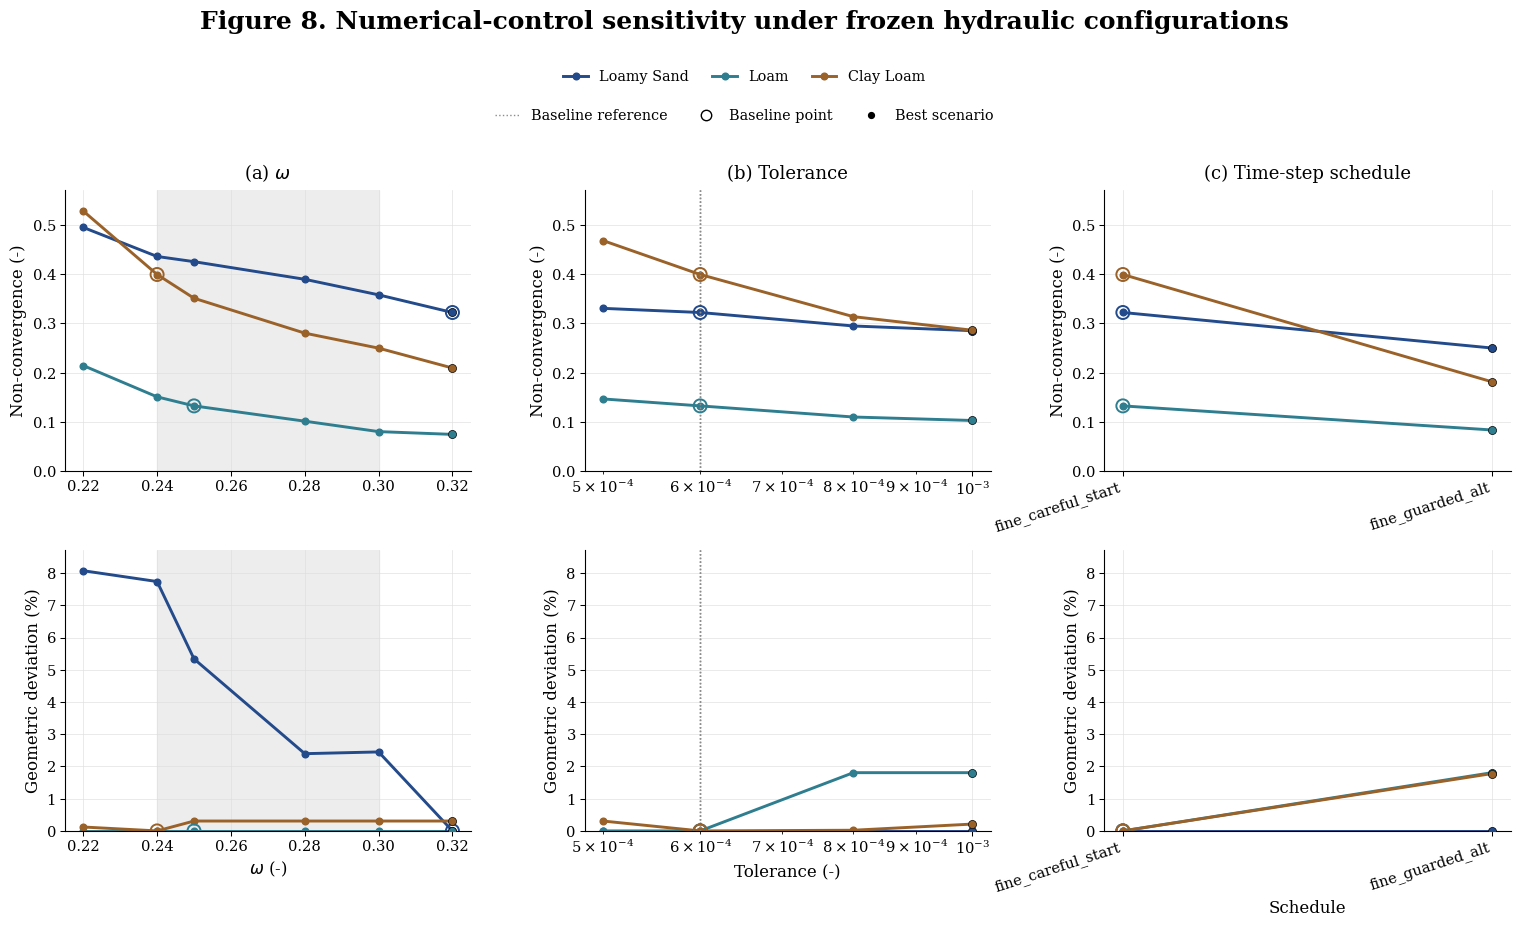

Figure 8 executed correctly.
Saved files:
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_8_numerical_controls.png
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_8_numerical_controls.pdf
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_8_numerical_controls.svg


In [13]:
# ==========================================================
# FIGURE 8 — NUMERICAL-CONTROL SENSITIVITY
# REPRODUCIBILITY RELEASE
# Numerical-control sensitivity under frozen hydraulic configurations
# - Reads CSV from saved_results
# - Panels: omega, tolerance, time-step schedule
# - Top row: non-convergence ratio
# - Bottom row: geometric deviation
# - Baseline reference highlighted
# - Baseline point highlighted
# - Best scenario highlighted
# - Export in PNG, PDF, and SVG
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------------------------------------
# 0. PATHS
# ----------------------------------------------------------
SAVE_DIR = os.getcwd()

FIGDIR = os.path.join((SAVE_DIR), "figures")
os.makedirs(FIGDIR, exist_ok=True)

csv_main = os.path.join(SAVE_DIR, "table_B_numerical_sensitivity.csv")
csv_fallback = os.path.join(SAVE_DIR, "results_summary.csv")

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
if os.path.exists(csv_main):
    numerical_sensitivity_df = pd.read_csv(csv_main)
    print("Loaded:", csv_main)

elif os.path.exists(csv_fallback):
    df_all = pd.read_csv(csv_fallback)
    print("table_B_numerical_sensitivity.csv not found.")
    print("Using fallback:", csv_fallback)

    required_cols = {"texture", "var_name", "var_value", "nonconv_ratio", "geometry_dev_pct"}
    if required_cols.issubset(df_all.columns):
        numerical_sensitivity_df = df_all.copy()
    else:
        raise ValueError(
            "table_B_numerical_sensitivity.csv was not found, and "
            "results_summary.csv does not contain the required columns."
        )
else:
    raise FileNotFoundError(
        "Neither of these files was found:\n"
        f" - {csv_main}\n"
        f" - {csv_fallback}"
    )

numerical_sensitivity_df.columns = [c.strip() for c in numerical_sensitivity_df.columns]

# ----------------------------------------------------------
# 2. BASIC CLEANING
# ----------------------------------------------------------
required_cols = ["texture", "var_name", "var_value", "nonconv_ratio", "geometry_dev_pct"]
missing = [c for c in required_cols if c not in numerical_sensitivity_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

numerical_sensitivity_df["nonconv_ratio"] = pd.to_numeric(
    numerical_sensitivity_df["nonconv_ratio"], errors="coerce"
)
numerical_sensitivity_df["geometry_dev_pct"] = pd.to_numeric(
    numerical_sensitivity_df["geometry_dev_pct"], errors="coerce"
)

numerical_sensitivity_df = numerical_sensitivity_df.dropna(
    subset=["texture", "var_name", "var_value", "nonconv_ratio", "geometry_dev_pct"]
).copy()

# ----------------------------------------------------------
# 3. FIGURE CONFIGURATION
# ----------------------------------------------------------
texture_order = ["Loamy Sand", "Loam", "Clay Loam"]

TEXTURE_COLORS = {
    "Loamy Sand": "#234a8a",
    "Loam": "#2f7e8f",
    "Clay Loam": "#9a6229"
}

vars_list = ["omega_default", "tol", "schedule_name"]
panel_titles = ["(a) $\\omega$", "(b) Tolerance", "(c) Time-step schedule"]

# Baseline numerical settings by texture
BASELINE_NUM = {
    "Loamy Sand": {"omega_default": 0.32, "tol": 6e-4, "schedule_name": "coarse_ultra_transition"},
    "Loam":       {"omega_default": 0.25, "tol": 6e-4, "schedule_name": "medium_safe_track"},
    "Clay Loam":  {"omega_default": 0.24, "tol": 6e-4, "schedule_name": "fine_careful_start"},
}

# Schedules to compare in each texture
SCHEDULE_SENSITIVITY_BY_TEXTURE = {
    "Loamy Sand": ["coarse_ultra_transition", "coarse_guarded_alt"],
    "Loam":       ["medium_safe_track", "medium_guarded_alt"],
    "Clay Loam":  ["fine_careful_start", "fine_guarded_alt"],
}

# Visual preferred omega band
OMEGA_OPT_LOW = 0.24
OMEGA_OPT_HIGH = 0.30

# ----------------------------------------------------------
# 4. STYLE
# ----------------------------------------------------------
FS_BASE = 11.6
FS_TICK = 10.6
FS_AXIS = 12.0
FS_TITLE = 13.0
FS_SUPTITLE = 18.0
FS_LEGEND = 10.4

plt.rcParams.update({
    "font.family": "serif",
    "font.size": FS_BASE,
    "axes.titlesize": FS_TITLE,
    "axes.labelsize": FS_AXIS,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "figure.titlesize": FS_SUPTITLE,
    "axes.linewidth": 0.85,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3.8,
    "ytick.major.size": 3.8,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

# ----------------------------------------------------------
# 5. AUXILIARY FUNCTIONS
# ----------------------------------------------------------
def style_axis(ax):
    ax.grid(True, which="major", color="#dddddd", linestyle="-", linewidth=0.50, alpha=0.88)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", width=0.75, pad=2.5)

def prettify_schedule_label(x):
    return str(x).replace("_", "_")

def find_best_point(df_sub):
    """
    Best scenario = lowest non-convergence,
    then lowest geometric deviation.
    """
    if len(df_sub) == 0:
        return None
    tmp = df_sub.sort_values(["nonconv_ratio", "geometry_dev_pct"], ascending=[True, True]).copy()
    return tmp.iloc[0]

# Only variables used in this figure
sub_all = numerical_sensitivity_df[
    numerical_sensitivity_df["var_name"].isin(vars_list)
].copy()

y_nonconv_max = sub_all["nonconv_ratio"].max() * 1.08
y_geom_max = max(0.10, sub_all["geometry_dev_pct"].max() * 1.08)

# ----------------------------------------------------------
# 6. FIGURE LAYOUT
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15.8, 8.6), sharex=False)

for c, var_name in enumerate(vars_list):
    sub = numerical_sensitivity_df[
        numerical_sensitivity_df["var_name"] == var_name
    ].copy()

    # ======================================================
    # TOP ROW — NON-CONVERGENCE
    # ======================================================
    ax = axes[0, c]

    if var_name == "omega_default":
        ax.axvspan(OMEGA_OPT_LOW, OMEGA_OPT_HIGH, color="0.93", alpha=0.95, zorder=0)

    for tex in texture_order:
        s = sub[sub["texture"] == tex].copy()
        color = TEXTURE_COLORS[tex]

        if len(s) == 0:
            continue

        if var_name == "schedule_name":
            order = SCHEDULE_SENSITIVITY_BY_TEXTURE[tex]
            mapping = {k: i for i, k in enumerate(order)}
            s["order"] = s["var_value"].map(mapping)
            s = s.dropna(subset=["order"]).sort_values("order")

            xx = np.arange(len(s))
            ax.plot(xx, s["nonconv_ratio"], "-o", color=color, lw=2.1, ms=4.8)

            # baseline point
            base_name = BASELINE_NUM[tex]["schedule_name"]
            s_base = s[s["var_value"] == base_name]
            if len(s_base) > 0:
                xb = s_base["order"].iloc[0]
                yb = s_base["nonconv_ratio"].iloc[0]
                ax.scatter(
                    xb, yb, s=88, facecolors="none", edgecolors=color,
                    linewidths=1.4, zorder=5
                )

            # best point
            best = find_best_point(s)
            if best is not None:
                xb = best["order"]
                yb = best["nonconv_ratio"]
                ax.scatter(
                    xb, yb, s=34, color=color, edgecolors="black",
                    linewidths=0.45, zorder=6
                )

            ax.set_xticks(xx)
            ax.set_xticklabels(order, rotation=18, ha="right")

        else:
            s["var_value_num"] = pd.to_numeric(s["var_value"], errors="coerce")
            s = s.dropna(subset=["var_value_num"]).sort_values("var_value_num")
            xx = s["var_value_num"].values

            ax.plot(xx, s["nonconv_ratio"], "-o", color=color, lw=2.1, ms=4.8)

            # baseline point
            xbase = BASELINE_NUM[tex][var_name]
            s_base = s[np.isclose(s["var_value_num"], float(xbase), equal_nan=False)]
            if len(s_base) > 0:
                xb = s_base["var_value_num"].iloc[0]
                yb = s_base["nonconv_ratio"].iloc[0]
                ax.scatter(
                    xb, yb, s=88, facecolors="none", edgecolors=color,
                    linewidths=1.4, zorder=5
                )

            # best point
            best = find_best_point(s)
            if best is not None:
                xb = float(best["var_value_num"])
                yb = best["nonconv_ratio"]
                ax.scatter(
                    xb, yb, s=34, color=color, edgecolors="black",
                    linewidths=0.45, zorder=6
                )

            # baseline reference line for tolerance
            if var_name == "tol":
                ax.axvline(6e-4, color="0.55", lw=1.0, ls=":")

    style_axis(ax)
    ax.set_title(panel_titles[c], pad=8)
    ax.set_ylabel("Non-convergence (-)")
    ax.set_ylim(0, y_nonconv_max)

    # ======================================================
    # BOTTOM ROW — GEOMETRIC DEVIATION
    # ======================================================
    ax2 = axes[1, c]

    if var_name == "omega_default":
        ax2.axvspan(OMEGA_OPT_LOW, OMEGA_OPT_HIGH, color="0.93", alpha=0.95, zorder=0)

    for tex in texture_order:
        s = sub[sub["texture"] == tex].copy()
        color = TEXTURE_COLORS[tex]

        if len(s) == 0:
            continue

        if var_name == "schedule_name":
            order = SCHEDULE_SENSITIVITY_BY_TEXTURE[tex]
            mapping = {k: i for i, k in enumerate(order)}
            s["order"] = s["var_value"].map(mapping)
            s = s.dropna(subset=["order"]).sort_values("order")

            xx = np.arange(len(s))
            ax2.plot(xx, s["geometry_dev_pct"], "-o", color=color, lw=2.1, ms=4.8)

            # baseline point
            base_name = BASELINE_NUM[tex]["schedule_name"]
            s_base = s[s["var_value"] == base_name]
            if len(s_base) > 0:
                xb = s_base["order"].iloc[0]
                yb = s_base["geometry_dev_pct"].iloc[0]
                ax2.scatter(
                    xb, yb, s=88, facecolors="none", edgecolors=color,
                    linewidths=1.4, zorder=5
                )

            # best point
            best = find_best_point(s)
            if best is not None:
                xb = best["order"]
                yb = best["geometry_dev_pct"]
                ax2.scatter(
                    xb, yb, s=34, color=color, edgecolors="black",
                    linewidths=0.45, zorder=6
                )

            ax2.set_xticks(xx)
            ax2.set_xticklabels(order, rotation=18, ha="right")

        else:
            s["var_value_num"] = pd.to_numeric(s["var_value"], errors="coerce")
            s = s.dropna(subset=["var_value_num"]).sort_values("var_value_num")
            xx = s["var_value_num"].values

            ax2.plot(xx, s["geometry_dev_pct"], "-o", color=color, lw=2.1, ms=4.8)

            # baseline point
            xbase = BASELINE_NUM[tex][var_name]
            s_base = s[np.isclose(s["var_value_num"], float(xbase), equal_nan=False)]
            if len(s_base) > 0:
                xb = s_base["var_value_num"].iloc[0]
                yb = s_base["geometry_dev_pct"].iloc[0]
                ax2.scatter(
                    xb, yb, s=88, facecolors="none", edgecolors=color,
                    linewidths=1.4, zorder=5
                )

            # best point
            best = find_best_point(s)
            if best is not None:
                xb = float(best["var_value_num"])
                yb = best["geometry_dev_pct"]
                ax2.scatter(
                    xb, yb, s=34, color=color, edgecolors="black",
                    linewidths=0.45, zorder=6
                )

            if var_name == "tol":
                ax2.axvline(6e-4, color="0.55", lw=1.0, ls=":")

    style_axis(ax2)
    ax2.set_ylabel("Geometric deviation (%)")
    ax2.set_ylim(0, y_geom_max)

    if var_name == "omega_default":
        ax2.set_xlabel("$\\omega$ (-)")
    elif var_name == "tol":
        ax2.set_xlabel("Tolerance (-)")
        ax.set_xscale("log")
        ax2.set_xscale("log")
    else:
        ax2.set_xlabel("Schedule")

# ----------------------------------------------------------
# 7. LEGENDS
# ----------------------------------------------------------
legend_tex = [
    Line2D([0], [0], color=TEXTURE_COLORS[t], lw=2.1, marker="o", ms=4.8, label=t)
    for t in texture_order
]

legend_extra = [
    Line2D([0], [0], color="0.55", lw=1.0, ls=":", label="Baseline reference"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="none", lw=0,
           markersize=7.5, label="Baseline point"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="black", lw=0,
           markersize=4.2, label="Best scenario"),
]

fig.legend(
    handles=legend_tex,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    handlelength=1.7,
    columnspacing=1.6
)

fig.legend(
    handles=legend_extra,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.975),
    handlelength=1.7,
    columnspacing=1.8
)

# ----------------------------------------------------------
# 8. TITLE + LAYOUT
# ----------------------------------------------------------
fig.suptitle(
    "Figure 8. Numerical-control sensitivity under frozen hydraulic configurations",
    y=1.075,
    fontweight="bold"
)

fig.subplots_adjust(
    top=0.865,
    bottom=0.12,
    left=0.07,
    right=0.985,
    wspace=0.28,
    hspace=0.28
)

# ----------------------------------------------------------
# 9. EXPORT
# ----------------------------------------------------------
out_png = os.path.join(FIGDIR, "Figure_8_numerical_controls.png")
out_pdf = os.path.join(FIGDIR, "Figure_8_numerical_controls.pdf")
out_svg = os.path.join(FIGDIR, "Figure_8_numerical_controls.svg")

fig.savefig(out_png, facecolor="white")
fig.savefig(out_pdf, facecolor="white")
fig.savefig(out_svg, facecolor="white")

plt.show()

print("Figure 8 executed correctly.")
print("Saved files:")
print(" -", out_png)
print(" -", out_pdf)
print(" -", out_svg)

# Figures 7 and 9, plus supplementary simulation-definition sensitivity
Hydraulic-parameter sensitivity, simulation-definition sensitivity, and computational runtime response.

INPUT FILE LOADED
CSV file: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\table_C_physical_sensitivity.csv
Output directory: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures
Rows loaded: 87
Columns: ['case_id', 'group_name', 'texture', 'phase_run_id', 'scenario_name', 'scenario_note', 'schedule_name', 'variant_name', 'h_init_common', 'max_iter', 'rescue_iter', 'tol', 'omega_default', 'max_dh_default', 'Q_Lh', 'emitter_radius_cm', 'fw_threshold', 't_final_h', 'depth_cm', 'radial_extent_cm', 'width_cm', 'volume_cm3', 'shape_ratio', 'nonconv_ratio', 'storage_ratio', 'rescued_steps', 'runtime_s', 'numerical_quality', 'var_name', 'var_value', 'x_for_plot', 'depth_rel_pct', 'radial_rel_pct', 'volume_rel_pct']

Runtime observations flagged as outliers: 7
Runtime trace table saved to: c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\fi

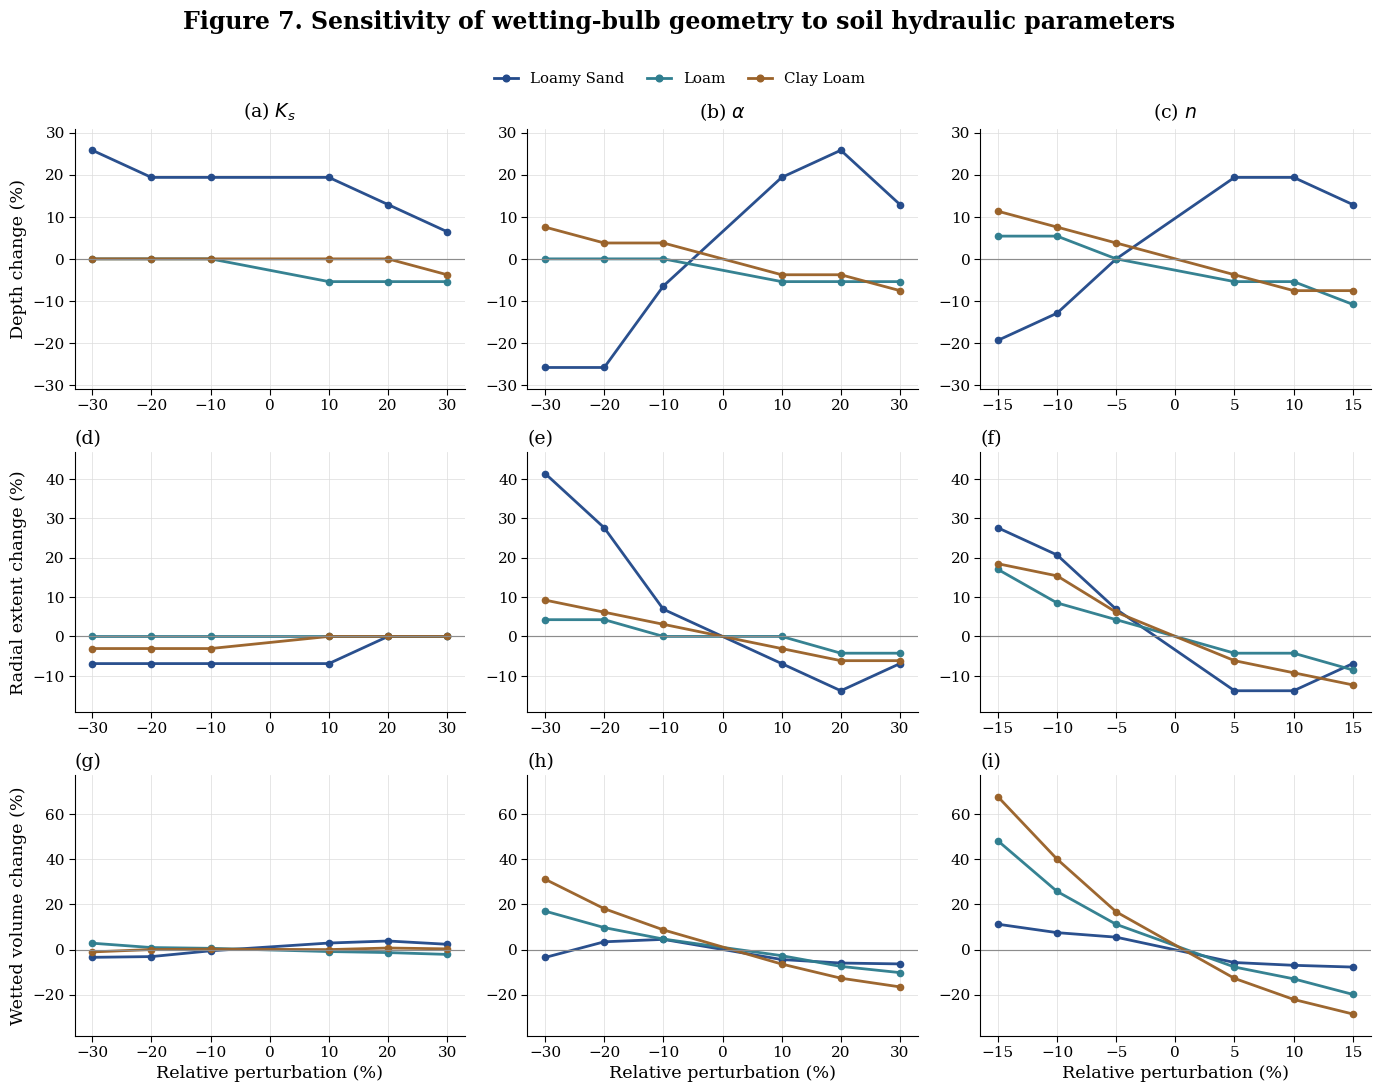

Figure 7 saved to:
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.png
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.pdf
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.svg


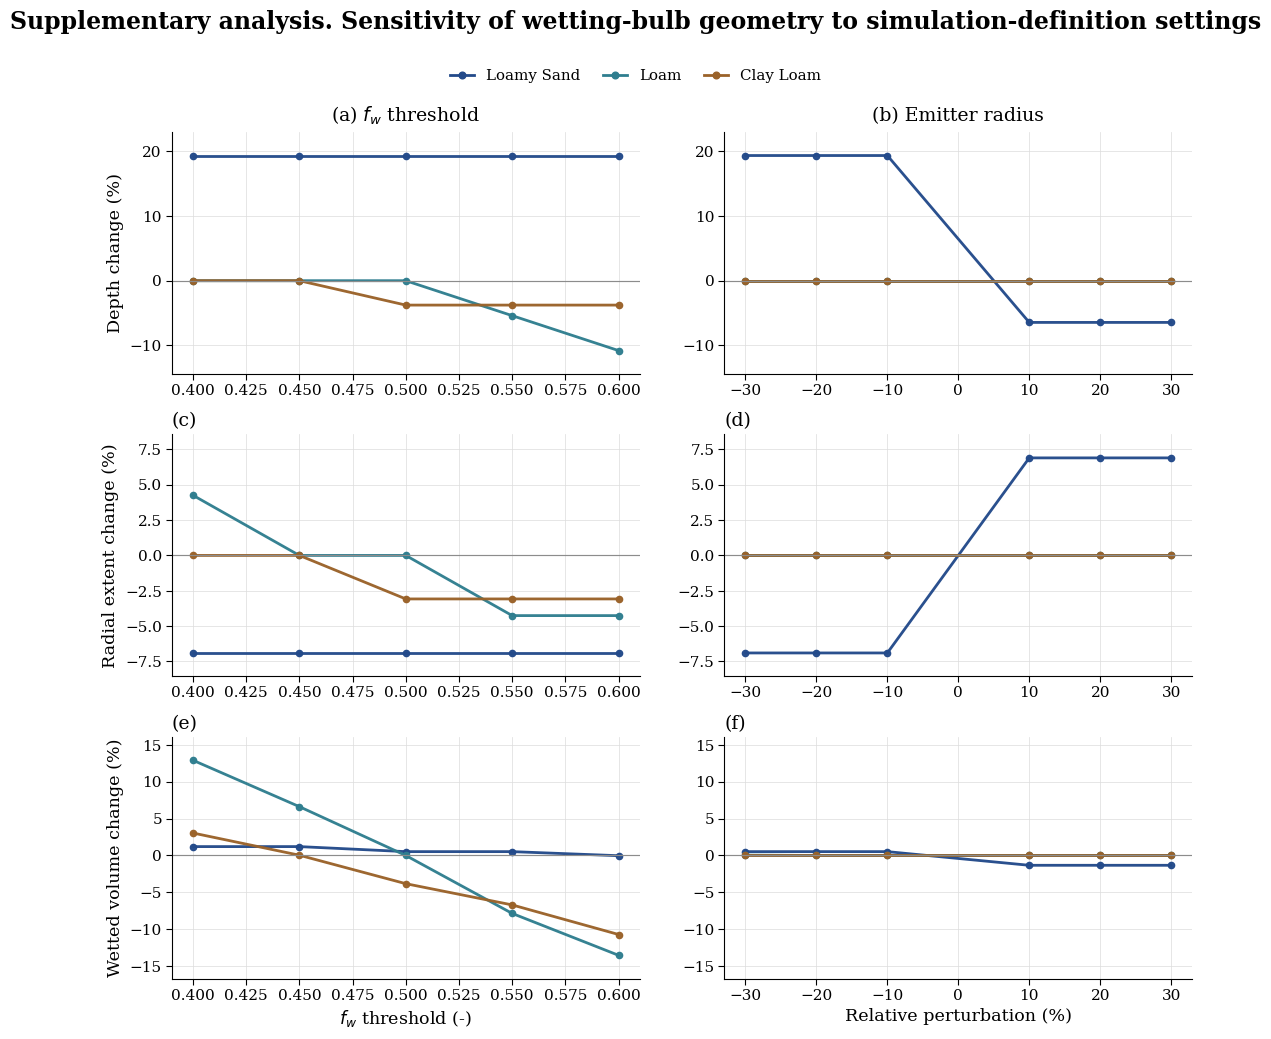

Supplementary sensitivity figure saved to:
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Supplementary_simulation_definition_sensitivity.png
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Supplementary_simulation_definition_sensitivity.pdf
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Supplementary_simulation_definition_sensitivity.svg


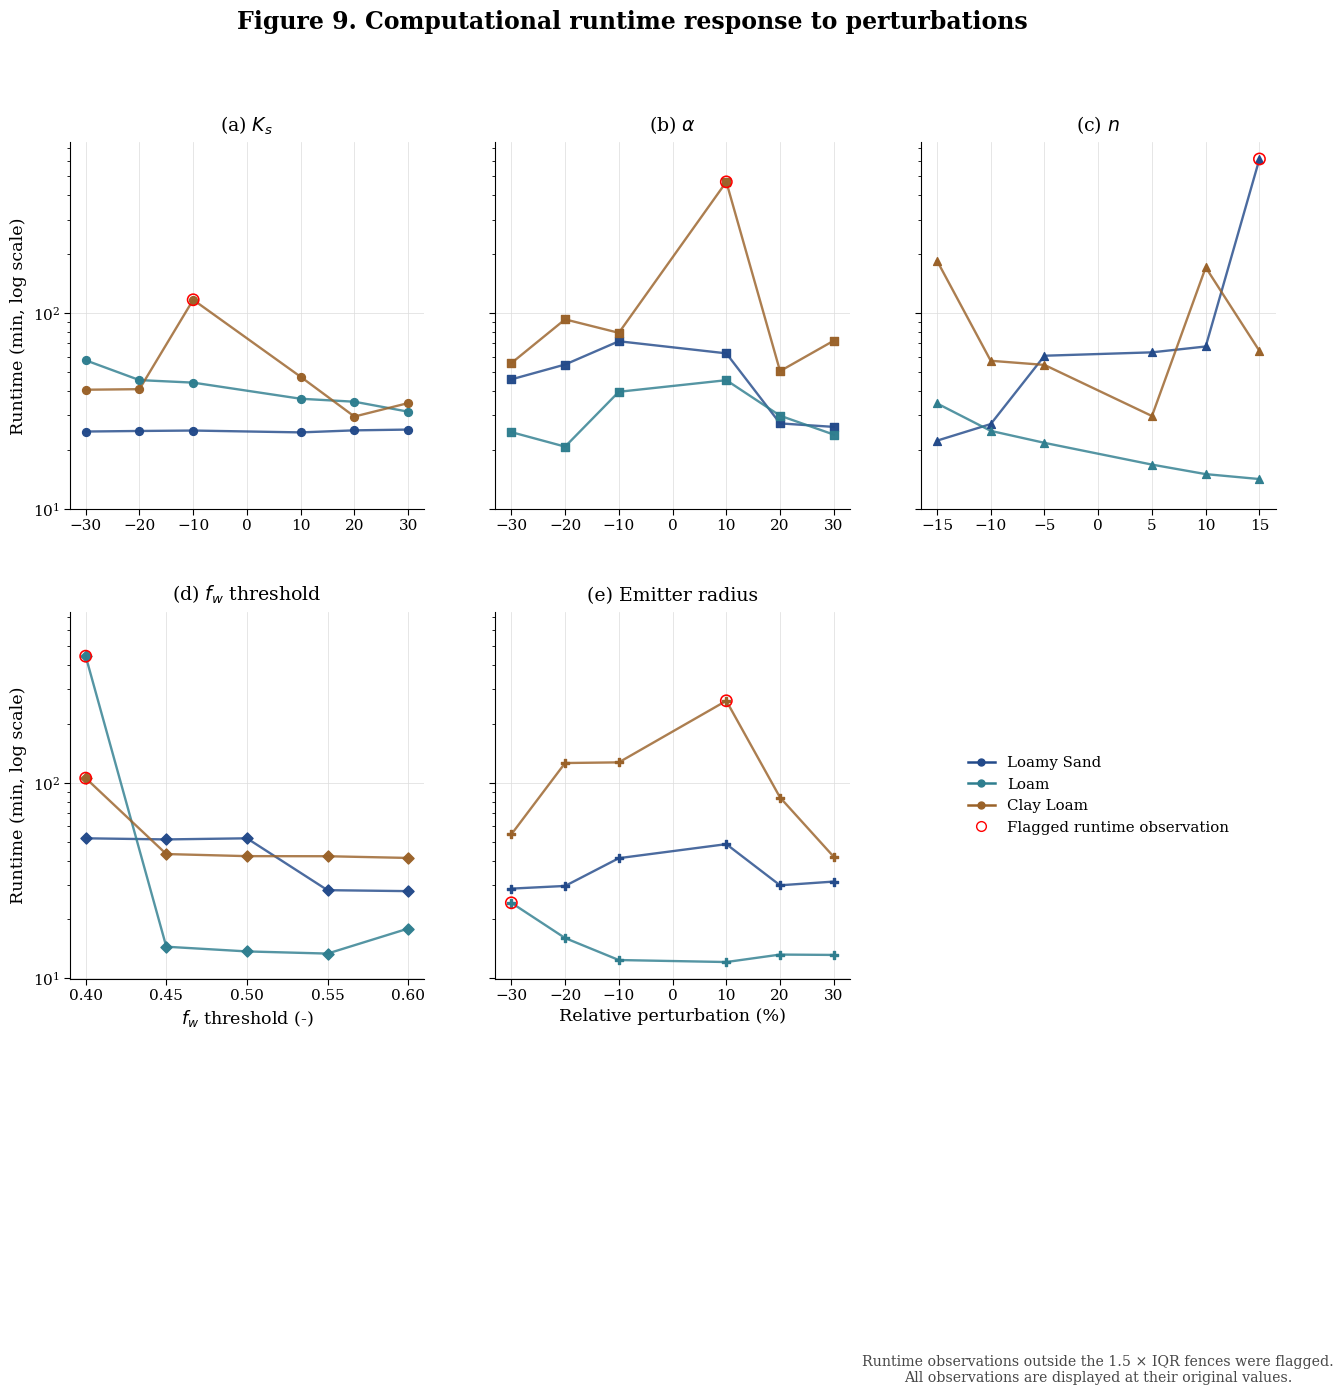

Figure 9 saved to:
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_9_runtime_response.png
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_9_runtime_response.pdf
 - c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_9_runtime_response.svg

GENERATED FILES
[OK] c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.png
[OK] c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.pdf
[OK] c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs\figures\Figure_7_hydraulic_sensitivity.svg
[OK] c:\Users\gguevara\OneDrive - Universidad EARTH\doctorado TEC\New folder\Solver_Aware_Wetting_Bulbs

In [14]:
# ==========================================================
# FIGURES 7 AND 9 + SUPPLEMENTARY SIMULATION-DEFINITION SENSITIVITY
#
# 7  = Sensitivity to soil hydraulic parameters (3x3)
# Supplementary = Sensitivity to simulation-definition settings (3x2)
# 9 = Runtime response (2x3)
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ----------------------------------------------------------
# 0. INPUT AND OUTPUT DIRECTORIES
# ----------------------------------------------------------

# Directory containing the input CSV file
BASE_DIR = os.getcwd()

# Directory used for all outputs
OUTPUT_DIR = os.path.join(BASE_DIR, "figures")

# Aliases retained for compatibility with the remaining code
SAVE_DIR = OUTPUT_DIR
FIGDIR = OUTPUT_DIR

# Create the output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input CSV file
table_c_path = os.path.join(
    BASE_DIR,
    "table_C_physical_sensitivity.csv"
)

if not os.path.isfile(table_c_path):
    raise FileNotFoundError(
        "Input file not found:\n"
        f"{table_c_path}"
    )

# Read CSV
physical_sensitivity_df = pd.read_csv(table_c_path)
df_phys = physical_sensitivity_df.copy()

print("=" * 80)
print("INPUT FILE LOADED")
print("=" * 80)
print("CSV file:", table_c_path)
print("Output directory:", OUTPUT_DIR)
print(f"Rows loaded: {len(df_phys)}")
print(f"Columns: {list(df_phys.columns)}")
print("=" * 80)


# ----------------------------------------------------------
# 1. FIGURE STYLE
# ----------------------------------------------------------

FS_BASE = 12.0
FS_TICK = 11.0
FS_AXIS = 12.6
FS_PANEL = 13.6
FS_SUPTITLE = 17.0
FS_LEGEND = 10.8
FS_NOTE = 10.2

plt.rcParams.update({
    "font.family": "serif",
    "font.size": FS_BASE,
    "axes.titlesize": FS_PANEL,
    "axes.labelsize": FS_AXIS,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "figure.titlesize": FS_SUPTITLE,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "savefig.dpi": 500,
    "savefig.bbox": "tight"
})


# ----------------------------------------------------------
# 2. FUNCTION TO SAVE PNG, PDF, AND SVG
# ----------------------------------------------------------

def save_figure_all_formats(fig, output_dir, base_filename, dpi=500):
    """
    Saves a figure in PNG, PDF, and SVG formats.
    base_filename must be provided without an extension.
    """

    png_path = os.path.join(output_dir, f"{base_filename}.png")
    pdf_path = os.path.join(output_dir, f"{base_filename}.pdf")
    svg_path = os.path.join(output_dir, f"{base_filename}.svg")

    fig.savefig(
        png_path,
        dpi=dpi,
        facecolor="white",
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        facecolor="white",
        bbox_inches="tight"
    )

    fig.savefig(
        svg_path,
        facecolor="white",
        bbox_inches="tight"
    )

    return png_path, pdf_path, svg_path


# ----------------------------------------------------------
# 3. GENERAL CONFIGURATION
# ----------------------------------------------------------

texture_order = [
    "Loamy Sand",
    "Loam",
    "Clay Loam"
]

TEXTURE_COLORS = {
    "Loamy Sand": "#234a8a",
    "Loam": "#2f7e8f",
    "Clay Loam": "#9a6229"
}

metric_order = [
    "depth_rel_pct",
    "radial_rel_pct",
    "volume_rel_pct"
]

metric_labels = {
    "depth_rel_pct": "Depth change (%)",
    "radial_rel_pct": "Radial extent change (%)",
    "volume_rel_pct": "Wetted volume change (%)"
}

var_labels = {
    "Ks": r"$K_s$",
    "alpha": r"$\alpha$",
    "n": r"$n$",
    "fw_threshold": r"$f_w$ threshold",
    "emitter_radius_cm": "Emitter radius"
}

runtime_markers = {
    "Ks": "o",
    "alpha": "s",
    "n": "^",
    "fw_threshold": "D",
    "emitter_radius_cm": "P"
}


# ----------------------------------------------------------
# 4. REQUIRED-COLUMN CHECK
# ----------------------------------------------------------

required_columns = [
    "texture",
    "var_name",
    "scenario_name",
    "x_for_plot",
    "depth_rel_pct",
    "radial_rel_pct",
    "volume_rel_pct",
    "runtime_s"
]

missing_columns = [
    col for col in required_columns
    if col not in df_phys.columns
]

if missing_columns:
    raise ValueError(
        "The CSV is missing the following required columns:\n"
        f"{missing_columns}"
    )


# ----------------------------------------------------------
# 5. RUNTIME OUTLIER FLAGGING
#    Observations are flagged but NEVER modified
# ----------------------------------------------------------

df_phys["runtime_min"] = (
    pd.to_numeric(
        df_phys["runtime_s"],
        errors="coerce"
    ) / 60.0
)

df_phys["runtime_outlier_flag"] = False

variables_sensitivity = [
    "Ks",
    "alpha",
    "n",
    "fw_threshold",
    "emitter_radius_cm"
]

for tex in texture_order:

    for var in variables_sensitivity:

        mask = (
            (df_phys["texture"] == tex)
            & (df_phys["var_name"] == var)
        )

        s = df_phys.loc[
            mask,
            "runtime_min"
        ].dropna()

        # IQR flagging is not applied to very small groups
        if len(s) < 4:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        out_mask = (
            mask
            & (
                (df_phys["runtime_min"] < lower)
                | (df_phys["runtime_min"] > upper)
            )
        )

        df_phys.loc[
            out_mask,
            "runtime_outlier_flag"
        ] = True


# ----------------------------------------------------------
# 6. EXPORT RUNTIME TRACEABILITY
# ----------------------------------------------------------

runtime_trace = df_phys[[
    "texture",
    "var_name",
    "scenario_name",
    "runtime_s",
    "runtime_min",
    "runtime_outlier_flag"
]].copy()

runtime_trace_path = os.path.join(
    SAVE_DIR,
    "table_D_runtime_trace_raw_and_flagged.csv"
)

runtime_trace.to_csv(
    runtime_trace_path,
    index=False
)

print(
    "\nRuntime observations flagged as outliers:",
    int(df_phys["runtime_outlier_flag"].sum())
)

print(
    "Runtime trace table saved to:",
    runtime_trace_path
)


# ----------------------------------------------------------
# 7. HELPER FUNCTIONS
# ----------------------------------------------------------

def _row_limits(
    df,
    vars_to_plot,
    metric_name,
    pad=0.08,
    symmetric=False
):

    sub = df[
        df["var_name"].isin(vars_to_plot)
    ]

    vals = sub[
        metric_name
    ].dropna().values

    if len(vals) == 0:
        return -1, 1

    vmin = np.min(vals)
    vmax = np.max(vals)

    if symmetric:

        vmax_abs = max(
            abs(vmin),
            abs(vmax)
        )

        return (
            -vmax_abs * (1 + pad),
            vmax_abs * (1 + pad)
        )

    value_range = vmax - vmin

    if value_range == 0:
        value_range = max(
            1.0,
            abs(vmax) * 0.15
        )

    return (
        vmin - pad * value_range,
        vmax + pad * value_range
    )


def _style_axis(ax):

    ax.grid(
        True,
        which="major",
        color="#dddddd",
        linestyle="-",
        linewidth=0.55,
        alpha=0.92
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        width=0.8,
        pad=3
    )


def _plot_texture_lines(
    ax,
    s,
    tex,
    marker="o",
    lw=2.0,
    ms=4.6,
    line_alpha=0.96
):

    ax.plot(
        s["x_for_plot"].values,
        s["yplot"].values,
        color=TEXTURE_COLORS[tex],
        lw=lw,
        marker=marker,
        ms=ms,
        alpha=line_alpha,
        solid_capstyle="round"
    )


def _add_texture_legend(
    fig,
    y=0.985
):

    legend_tex = [

        Line2D(
            [0],
            [0],
            color=TEXTURE_COLORS[texture],
            lw=2.0,
            marker="o",
            ms=4.8,
            label=texture
        )

        for texture in texture_order
    ]

    fig.legend(
        handles=legend_tex,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, y),
        handlelength=1.6,
        columnspacing=1.5
    )


# ----------------------------------------------------------
# 8. FIGURE 7 — HYDRAULIC SENSITIVITY (3 × 3)
# ----------------------------------------------------------

def plot_hydraulic_3x3(df):

    vars_to_plot = [
        "Ks",
        "alpha",
        "n"
    ]

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(14.4, 10.8),
        sharex=False
    )

    panel_letters = list(
        "abcdefghi"
    )

    row_lims = {

        metric: _row_limits(
            df,
            vars_to_plot,
            metric,
            pad=0.10,
            symmetric=False
        )

        for metric in metric_order
    }

    for column_index, var_name in enumerate(
        vars_to_plot
    ):

        sub_var = df[
            df["var_name"] == var_name
        ].copy()

        for row_index, metric_column in enumerate(
            metric_order
        ):

            ax = axes[
                row_index,
                column_index
            ]

            panel_index = (
                row_index * 3
                + column_index
            )

            for texture in texture_order:

                s = sub_var[
                    sub_var["texture"] == texture
                ].copy()

                if len(s) == 0:
                    continue

                s = s.sort_values(
                    "x_for_plot"
                ).copy()

                s["yplot"] = (
                    s[metric_column].values
                )

                _plot_texture_lines(
                    ax,
                    s,
                    texture,
                    marker="o",
                    lw=2.0,
                    ms=4.5,
                    line_alpha=0.97
                )

            ax.axhline(
                0,
                color="0.55",
                lw=0.85
            )

            ax.set_ylim(
                *row_lims[metric_column]
            )

            _style_axis(ax)

            if row_index == 0:

                ax.set_title(
                    f"({panel_letters[panel_index]}) "
                    f"{var_labels[var_name]}",
                    pad=8
                )

            else:

                ax.set_title(
                    f"({panel_letters[panel_index]})",
                    pad=6,
                    loc="left"
                )

            if column_index == 0:

                ax.set_ylabel(
                    metric_labels[
                        metric_column
                    ]
                )

            if row_index == 2:

                ax.set_xlabel(
                    "Relative perturbation (%)"
                )

    _add_texture_legend(
        fig,
        y=0.985
    )

    fig.suptitle(
        "Figure 7. Sensitivity of wetting-bulb geometry "
        "to soil hydraulic parameters",
        y=1.03,
        fontweight="bold"
    )

    fig.subplots_adjust(
        top=0.92,
        bottom=0.08,
        left=0.08,
        right=0.98,
        wspace=0.16,
        hspace=0.24
    )

    png_path, pdf_path, svg_path = (
        save_figure_all_formats(
            fig,
            FIGDIR,
            "Figure_7_hydraulic_sensitivity",
            dpi=500
        )
    )

    plt.show()

    print(
        "Figure 7 saved to:"
    )

    print(" -", png_path)
    print(" -", pdf_path)
    print(" -", svg_path)

    return (
        png_path,
        pdf_path,
        svg_path
    )


# ----------------------------------------------------------
# 9. SUPPLEMENTARY ANALYSIS
#    SIMULATION-DEFINITION SETTINGS (3 × 2)
# ----------------------------------------------------------

def plot_simulation_physical_3x2(df):

    vars_to_plot = [
        "fw_threshold",
        "emitter_radius_cm"
    ]

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(11.6, 10.2),
        sharex=False
    )

    panel_letters = list(
        "abcdef"
    )

    row_lims = {

        metric: _row_limits(
            df,
            vars_to_plot,
            metric,
            pad=0.12,
            symmetric=False
        )

        for metric in metric_order
    }

    for column_index, var_name in enumerate(
        vars_to_plot
    ):

        sub_var = df[
            df["var_name"] == var_name
        ].copy()

        for row_index, metric_column in enumerate(
            metric_order
        ):

            ax = axes[
                row_index,
                column_index
            ]

            panel_index = (
                row_index * 2
                + column_index
            )

            for texture in texture_order:

                s = sub_var[
                    sub_var["texture"] == texture
                ].copy()

                if len(s) == 0:
                    continue

                s = s.sort_values(
                    "x_for_plot"
                ).copy()

                s["yplot"] = (
                    s[metric_column].values
                )

                _plot_texture_lines(
                    ax,
                    s,
                    texture,
                    marker="o",
                    lw=2.0,
                    ms=4.5,
                    line_alpha=0.97
                )

            ax.axhline(
                0,
                color="0.55",
                lw=0.85
            )

            ax.set_ylim(
                *row_lims[
                    metric_column
                ]
            )

            _style_axis(ax)

            if row_index == 0:

                ax.set_title(
                    f"({panel_letters[panel_index]}) "
                    f"{var_labels[var_name]}",
                    pad=8
                )

            else:

                ax.set_title(
                    f"({panel_letters[panel_index]})",
                    pad=6,
                    loc="left"
                )

            if column_index == 0:

                ax.set_ylabel(
                    metric_labels[
                        metric_column
                    ]
                )

            if row_index == 2:

                if var_name == "fw_threshold":

                    ax.set_xlabel(
                        r"$f_w$ threshold (-)"
                    )

                else:

                    ax.set_xlabel(
                        "Relative perturbation (%)"
                    )

    _add_texture_legend(
        fig,
        y=0.985
    )

    fig.suptitle(
        "Supplementary analysis. Sensitivity of wetting-bulb geometry "
        "to simulation-definition settings",
        y=1.03,
        fontweight="bold"
    )

    fig.subplots_adjust(
        top=0.91,
        bottom=0.08,
        left=0.10,
        right=0.98,
        wspace=0.18,
        hspace=0.25
    )

    png_path, pdf_path, svg_path = (
        save_figure_all_formats(
            fig,
            FIGDIR,
            "Supplementary_simulation_definition_sensitivity",
            dpi=500
        )
    )

    plt.show()

    print(
        "Supplementary sensitivity figure saved to:"
    )

    print(" -", png_path)
    print(" -", pdf_path)
    print(" -", svg_path)

    return (
        png_path,
        pdf_path,
        svg_path
    )


# ----------------------------------------------------------
# 10. FIGURE 9 — RUNTIME (2 × 3)
# ----------------------------------------------------------

def plot_runtime_2x3(df):

    vars_to_plot = [
        "Ks",
        "alpha",
        "n",
        "fw_threshold",
        "emitter_radius_cm"
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(13.4, 10.2),
        sharey=True
    )

    axes = axes.ravel()

    panel_letters = list(
        "abcdef"
    )

    for index, var_name in enumerate(
        vars_to_plot
    ):

        ax = axes[index]

        sub = df[
            df["var_name"] == var_name
        ].copy()

        for texture in texture_order:

            s = sub[
                sub["texture"] == texture
            ].copy()

            if len(s) == 0:
                continue

            s = s.sort_values(
                "x_for_plot"
            ).copy()

            # Plot ORIGINAL runtime values
            ax.plot(
                s["x_for_plot"].values,
                s["runtime_min"].values,
                color=TEXTURE_COLORS[
                    texture
                ],
                lw=1.7,
                alpha=0.82
            )

            ax.scatter(
                s["x_for_plot"].values,
                s["runtime_min"].values,
                color=TEXTURE_COLORS[
                    texture
                ],
                s=32,
                marker=runtime_markers[
                    var_name
                ],
                alpha=0.98,
                zorder=4
            )

            # Highlight flagged observations
            # at their ORIGINAL runtime value
            sout = s[
                s["runtime_outlier_flag"]
            ].copy()

            if len(sout) > 0:

                ax.scatter(
                    sout[
                        "x_for_plot"
                    ].values,
                    sout[
                        "runtime_min"
                    ].values,
                    s=66,
                    facecolors="none",
                    edgecolors="red",
                    linewidths=1.15,
                    zorder=5
                )

        ax.set_yscale(
            "log"
        )

        _style_axis(
            ax
        )

        ax.set_title(
            f"({panel_letters[index]}) "
            f"{var_labels[var_name]}",
            pad=8
        )

        if index in [0, 3]:

            ax.set_ylabel(
                "Runtime (min, log scale)"
            )

        if index >= 3:

            if var_name == "fw_threshold":

                ax.set_xlabel(
                    r"$f_w$ threshold (-)"
                )

            else:

                ax.set_xlabel(
                    "Relative perturbation (%)"
                )

    # ------------------------------------------------------
    # Sixth panel: legend and methodological note
    # ------------------------------------------------------

    ax_leg = axes[5]

    ax_leg.axis(
        "off"
    )

    legend_tex = [

        Line2D(
            [0],
            [0],
            color=TEXTURE_COLORS[
                texture
            ],
            lw=1.8,
            marker="o",
            ms=5,
            label=texture
        )

        for texture in texture_order
    ]

    legend_out = [

        Line2D(
            [0],
            [0],
            color="red",
            marker="o",
            lw=0,
            markerfacecolor="none",
            markersize=7,
            label="Flagged runtime observation"
        )
    ]

    ax_leg.legend(
        handles=(
            legend_tex
            + legend_out
        ),
        loc="center",
        frameon=False,
        ncol=1,
        handlelength=1.8
    )

    ax_leg.text(
        0.5,
        0.10,
        "Runtime observations outside the 1.5 × IQR fences were flagged.\n"
        "All observations are displayed at their original values.",
        ha="center",
        va="center",
        fontsize=FS_NOTE,
        color="0.28"
    )

    fig.suptitle(
        "Figure 9. Computational runtime response "
        "to perturbations",
        y=1.03,
        fontweight="bold"
    )

    fig.subplots_adjust(
        top=0.90,
        bottom=0.08,
        left=0.08,
        right=0.98,
        wspace=0.20,
        hspace=0.28
    )

    png_path, pdf_path, svg_path = (
        save_figure_all_formats(
            fig,
            FIGDIR,
            "Figure_9_runtime_response",
            dpi=500
        )
    )

    plt.show()

    print(
        "Figure 9 saved to:"
    )

    print(" -", png_path)
    print(" -", pdf_path)
    print(" -", svg_path)

    return (
        png_path,
        pdf_path,
        svg_path
    )


# ----------------------------------------------------------
# 11. RUNTIME SUMMARY TABLE
#    Summary based entirely on ORIGINAL runtime observations
# ----------------------------------------------------------

runtime_summary = (
    df_phys
    .groupby(
        [
            "texture",
            "var_name"
        ]
    )[[
        "runtime_min"
    ]]
    .agg(
        [
            "min",
            "median",
            "max",
            "mean"
        ]
    )
)

runtime_summary_path = os.path.join(
    SAVE_DIR,
    "table_E_runtime_summary_raw.csv"
)

runtime_summary.to_csv(
    runtime_summary_path
)

print(
    "Runtime summary table saved to:",
    runtime_summary_path
)


# ----------------------------------------------------------
# 12. EXECUTION
# ----------------------------------------------------------

fig7_paths = plot_hydraulic_3x3(
    df_phys
)

supplementary_paths = (
    plot_simulation_physical_3x2(
        df_phys
    )
)

fig9_paths = plot_runtime_2x3(
    df_phys
)


# ----------------------------------------------------------
# 13. FINAL SUMMARY
# ----------------------------------------------------------

generated_files = [

    *fig7_paths,

    *supplementary_paths,

    *fig9_paths,

    runtime_trace_path,

    runtime_summary_path
]

print(
    "\n"
    + "=" * 80
)

print(
    "GENERATED FILES"
)

print(
    "=" * 80
)

for generated_file in generated_files:

    status = (
        "OK"
        if os.path.isfile(
            generated_file
        )
        else
        "NOT GENERATED"
    )

    print(
        f"[{status}] "
        f"{generated_file}"
    )

print(
    "=" * 80
)